# Poke Analysis

### Outline: 

1. Ingest dataframes with poke data
2. Poke rate analysis
3. Poke duration analysis

In [ ]:
# import python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib.cm as cm
import matplotlib.lines as mlines
import pathlib
import datetime
from typing import Dict, Tuple, Any
from collections import defaultdict
import swc.aeon.io.api as aeon_api
from zoneinfo import ZoneInfo
from scipy.stats import ttest_rel, wilcoxon, shapiro
from scipy.stats import gaussian_kde
from scipy.signal import savgol_filter, find_peaks


### Ingest CSVs

In [2]:
# Function to load and concatenate csvs in a common root directory
def load_csvs_with_subject_id(root_dir: str) -> pd.DataFrame:
    root = pathlib.Path(root_dir)
    dfs = []

    for csv_path in root.rglob("*.csv"):
        # subject_id is the first directory under root
        subject_id = csv_path.relative_to(root).parts[0]

        df = pd.read_csv(csv_path)
        df["subject_id"] = subject_id
        df["source_path"] = str(csv_path)  # optional but often useful

        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [ ]:
# Data root directory
root_dir = pathlib.Path(r"C:\Users\brandon.pratt\Desktop\results")
result_dir = root_dir.joinpath("figures")

# Load concatenated dataframe
df = load_csvs_with_subject_id(root_dir)

In [17]:
df

,poke_port,poke_registered,poke_number,configured_min_poke_duration,beam_break_onset,beam_break_offset,beam_break_duration,poke_onset,poke_offset,poke_duration,...,final_valve_vacuum_offset,final_valve_vacuum_duration,configured_final_valve_vacuum_duration,next_odor_setup_onset,next_odor_setup_offset,next_odor_setup_duration,configured_next_odor_setup_duration,detected_error,subject_id,source_path
0,1,True,1.0,0.01,3.850585e+09,3.850585e+09,0.286656,3.850585e+09,3.850585e+09,0.276608,...,3.850585e+09,0.000192,0.0,3.850585e+09,3.850585e+09,0.110240,0.02,NaN,801055,C:\Users\brandon.pratt\Desktop\results\801055\...
1,1,True,2.0,0.01,3.850585e+09,3.850585e+09,0.511104,3.850585e+09,3.850585e+09,0.501056,...,3.850585e+09,0.000224,0.0,3.850585e+09,3.850585e+09,0.113472,0.02,NaN,801055,C:\Users\brandon.pratt\Desktop\results\801055\...
2,1,True,3.0,0.01,3.850585e+09,3.850585e+09,0.392128,3.850585e+09,3.850585e+09,0.382112,...,3.850585e+09,0.000224,0.0,3.850585e+09,3.850585e+09,0.101664,0.02,NaN,801055,C:\Users\brandon.pratt\Desktop\results\801055\...
3,1,True,4.0,0.01,3.850585e+09,3.850585e+09,0.450656,3.850585e+09,3.850585e+09,0.440608,...,3.850585e+09,0.000192,0.0,3.850585e+09,3.850585e+09,0.115777,0.02,NaN,801055,C:\Users\brandon.pratt\Desktop\results\801055\...
4,1,True,5.0,0.01,3.850585e+09,3.850585e+09,0.187200,3.850585e+09,3.850585e+09,0.177184,...,3.850585e+09,0.000192,0.0,3.850585e+09,3.850585e+09,0.113248,0.02,NaN,801055,C:\Users\brandon.pratt\Desktop\results\801055\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11905,1,True,4015.0,0.01,3.854695e+09,3.854695e+09,0.415744,3.854695e+09,3.854695e+09,0.405696,...,3.854695e+09,0.000192,0.0,3.854695e+09,3.854695e+09,0.116352,0.02,NaN,835602,C:\Users\brandon.pratt\Desktop\results\835602\...
11906,1,True,4016.0,0.01,3.854695e+09,3.854695e+09,0.310784,3.854695e+09,3.854695e+09,0.300736,...,3.854695e+09,0.000224,0.0,3.854695e+09,3.854695e+09,0.112576,0.02,NaN,835602,C:\Users\brandon.pratt\Desktop\results\835602\...
11907,1,True,4017.0,0.01,3.854698e+09,3.854698e+09,0.106400,3.854698e+09,3.854698e+09,0.096352,...,3.854698e+09,0.000192,0.0,3.854698e+09,3.854698e+09,0.113152,0.02,NaN,835602,C:\Users\brandon.pratt\Desktop\results\835602\...
11908,1,True,4018.0,0.01,3.854698e+09,3.854698e+09,0.043392,3.854698e+09,3.854698e+09,0.033344,...,3.854698e+09,0.000192,0.0,3.854698e+09,3.854698e+09,0.110464,0.02,NaN,835602,C:\Users\brandon.pratt\Desktop\results\835602\...


### Poke rates and duration measures

#### Odor change events

In [ ]:
# function for finding the poke where the odor changed
def odor_change_events(
    data: pd.DataFrame,
    subject: str,
    source_path: str,
    odor_mapping: dict = None,
    odor_switch_times: list = None,
) -> tuple:
    if odor_mapping is None:
        odor_mapping = {}

    data = data.dropna(
        subset=["poke_onset", "odor"]
    )  # Ensure no NaN values in critical columns
    subject_data = data[data["subject_id"] == subject]
    source_data = subject_data[subject_data["source_path"] == source_path].dropna(
        subset=["poke_onset", "odor", "beam_break_onset"]
    )

    # Assuming 'poke_onset' is the column with poke timestamps and 'odor' is the column with odor values
    source_data["odor_change"] = source_data["odor"].diff() != 0

    t0 = min(source_data["beam_break_onset"])
    odor_change_pokes = source_data[source_data["odor_change"]]["poke_onset"] - t0

    if odor_switch_times is None:
        odor_switch_t = []
    else:
        odor_switch_t = [t - t0 for t in odor_switch_times]

    odor_ids = (
        source_data[source_data["odor_change"]]["odor"]
        .astype(int)
        .map(odor_mapping)
        .tolist()
    )
    return odor_change_pokes.tolist(), odor_ids, odor_switch_t

In [249]:
# PST datetime of actual odor switch
# Air -> Pinene, Pinene -> Air, Air -> Grass, Grass -> Air, Air -> Pinene, Pinene -> Air
datetime_801055 = [
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 1, 13, 13, 26, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 1, 20, 13, 52, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 1, 27, 14, 55, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(2026, 2, 3, 15, 43, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 2, 10, 14, 55, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(2026, 2, 17, 16, 8, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
]

datetime_835602 = [
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 1, 13, 13, 28, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(2026, 1, 20, 14, 0, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 1, 27, 14, 51, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(2026, 2, 3, 15, 46, 0, tzinfo=ZoneInfo("America/Los_Angeles"))
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 2, 10, 14, 52, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
    aeon_api.to_seconds(
        datetime.datetime(
            2026, 2, 17, 16, 13, 0, tzinfo=ZoneInfo("America/Los_Angeles")
        )
        .astimezone(ZoneInfo("UTC"))
        .replace(tzinfo=None)
    ),
]

odor_switch_t_subjects = [datetime_801055, datetime_835602]

In [255]:
# Get odor transition events and times
odor_mapping = {
    100: "Air",
    1000: "Pinene",
    10000: "Grass",
    # Add more mappings as needed
}

subjects = df["subject_id"].unique()
source_paths = df["source_path"].unique()

odor_events = {}

for subject in subjects:
    for source_path in source_paths:
        if subject in source_path:
            changes, odor_ids, odor_switch_t = odor_change_events(
                df,
                subject,
                source_path,
                odor_mapping,
                odor_switch_t_subjects[subjects.tolist().index(subject)],
            )

            # Initialize entry once per subject+file
            key = (subject, source_path)
            odor_events[key] = {"first_poke_t": [], "odor_id": []}

            for change_t, odor_id in zip(changes, odor_ids):
                print(
                    f"Subject: {subject}, Source: {source_path}, "
                    f"Odor Change Poke: {change_t}, Odor ID: {odor_id}"
                )

                odor_events[key]["first_poke_t"].append(change_t)
                odor_events[key]["odor_id"].append(odor_id)
                odor_events[key]["odor_switch_t"] = odor_switch_t

Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 0.01004791259765625, Odor ID: Air
Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 624163.8850235939, Odor ID: Pinene
Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 1210071.9658875465, Odor ID: Air
Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 1820301.669599533, Odor ID: Grass
Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 2438658.824511528, Odor ID: Air
Subject: 801055, Source: C:\Users\brandon.pratt\Desktop\results\801055\2026-01-06T22-49-36\delphi_qc_dataframe.csv, Odor Change Poke: 3028975.077152729, Odor ID: 

In [256]:
odor_events

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv'): {'first_poke_t': [0.01004791259765625,
   624163.8850235939,
   1210071.9658875465,
   1820301.669599533,
   2438658.824511528,
   3028975.077152729,
   3646231.2347836494],
  'odor_id': ['Air', 'Pinene', 'Air', 'Grass', 'Air', 'Pinene', 'Air'],
  'odor_switch_t': [599591.3093757629,
   1205951.309375763,
   1814531.309375763,
   2422211.309375763,
   3024131.309375763,
   3633311.309375763]},
 ('835602',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\835602\\2026-01-06T22-17-14\\delphi_qc_dataframe.csv'): {'first_poke_t': [0.01004791259765625,
   625098.1182079315,
   1208793.1154561043,
   1829336.5075201988,
   2436253.698656082,
   3037501.59523201,
   3647938.196352005],
  'odor_id': ['Air', 'Pinene', 'Air', 'Grass', 'Air', 'Pinene', 'Air'],
  'odor_switch_t': [601422.3474559784,
   1208142.3474559784,
   1816002.3474559784,
   2424102.3474559784,
   3025662.347455978

#### Poke events, rates, and durations

In [ ]:
# function for computing poke rate using an impulse function with an exponential decay kernel
def poke_rate_exponential_decay_binned(
    t_events: list, tau: float = 10, dt: float = 1800
):
    """
    Compute exponentially decaying poke rate from event times.

    Parameters
    ----------
    t_events : array-like
        Event times (seconds)
    tau : float
        Decay time constant (seconds)
    dt : float
        Time step (seconds)
    """
    t_events = np.asarray(t_events, dtype=float)

    if t_events.size == 0:
        return np.array([]), np.array([])

    t_events = np.sort(t_events)

    t0, t1 = t_events[0], t_events[-1]
    t_grid = np.arange(t0, t1 + dt, dt)

    s = 0.0
    r_grid = np.zeros_like(t_grid)
    e_idx = 0

    for i, tg in enumerate(t_grid):
        if i > 0:
            s *= np.exp(-dt / tau)  # exponential decay

        while e_idx < len(t_events) and t_events[e_idx] <= tg:
            s += 1.0  # impulse
            e_idx += 1

        r_grid[i] = s / tau

    return t_grid, r_grid


In [55]:
def poke_rate_exponential_decay_sliding(
    t_events: list,
    tau: float = 10.0,
    window: float = 60.0,
    overlap: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute poke rate using an exponential decay kernel over overlapping
    sliding windows.

    Parameters
    ----------
    t_events : sequence of float
        Poke event times (seconds), assumed >= 0.
    tau : float
        Exponential decay time constant (seconds).
    window : float
        Window length (seconds).
    overlap : float
        Fractional overlap between consecutive windows in [0, 1).
        For example:
        0.0 = no overlap
        0.5 = 50% overlap
        0.75 = 75% overlap

    Returns
    -------
    t_centers : np.ndarray
        Centers of sliding windows (seconds).
    rate : np.ndarray
        Poke rate (Hz) at each window center.
    """
    if not 0 <= overlap < 1:
        raise ValueError("overlap must be in the range [0, 1).")

    t_events = np.asarray(t_events, dtype=float)

    if t_events.size == 0:
        return np.array([]), np.array([])

    t_events = np.sort(t_events)

    # Step size derived from overlap
    step = window * (1.0 - overlap)

    t_start = t_events[0]
    t_end = t_events[-1]

    # Window centers
    t_centers = np.arange(t_start, t_end + step, step)
    rates = np.zeros_like(t_centers)

    for i, t_c in enumerate(t_centers):
        # Select events within the causal window
        mask = (t_events <= t_c) & (t_events >= t_c - window)
        relevant_events = t_events[mask]

        if relevant_events.size == 0:
            continue

        # Time since each contributing event
        dt = t_c - relevant_events

        # Exponential impulse response
        rates[i] = np.sum(np.exp(-dt / tau)) / tau

    return t_centers, rates

In [128]:
def poke_rate_exponential_decay_convolution(
    t_events: list[float],
    tau: float = 10.0,
    window: float = 60.0,
    overlap: float = 0.5,
    dt_kernel: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute poke rate by convolving an impulse train with a causal
    exponentially decaying kernel, sampled over overlapping windows.

    Parameters
    ----------
    t_events : sequence of float
        Poke event times in seconds (absolute or relative).
    tau : float
        Exponential decay time constant (seconds).
    window : float
        Sliding window length (seconds).
    overlap : float
        Fractional overlap between consecutive windows [0, 1).
    dt_kernel : float
        Temporal resolution of the impulse train / convolution (seconds).

    Returns
    -------
    t_centers : np.ndarray
        Window center times (seconds).
    rate : np.ndarray
        Poke rate (Hz) at each window center.
    """
    if not 0 <= overlap < 1:
        raise ValueError("overlap must be in the range [0, 1).")

    t_events = np.asarray(t_events, dtype=float)
    if t_events.size == 0:
        return np.array([]), np.array([])

    t_events = np.sort(t_events)

    # --- Define time grid ---
    t_start = t_events.min()
    t_end = t_events.max() + window
    t_grid = np.arange(t_start, t_end, dt_kernel)

    # --- Build impulse train ---
    impulse = np.zeros_like(t_grid)
    indices = ((t_events - t_start) / dt_kernel).astype(int)
    indices = indices[indices < len(impulse)]
    np.add.at(impulse, indices, 1.0)

    # --- Exponential kernel (causal) ---
    kernel_t = np.arange(0, window, dt_kernel)
    kernel = np.exp(-kernel_t / tau) / tau

    # --- Convolution ---
    rate_full = np.convolve(impulse, kernel, mode="full")[: len(t_grid)]

    # --- Sliding window centers ---
    step = window * (1 - overlap)
    t_centers = np.arange(t_events.min(), t_events.max(), step)

    center_idx = ((t_centers - t_start) / dt_kernel).astype(int)
    valid = (center_idx >= 0) & (center_idx < len(rate_full))

    return t_centers[valid], rate_full[center_idx[valid]]


In [257]:
# Poke rate function
def compute_poke_stats(
    df: pd.DataFrame,
    odor_events: Dict[Tuple[str, str], Dict[str, list]],
    tau: float = 10.0,
    dt: float = 1800.0,
    overlap: float = 0.5,
) -> Dict[Tuple[str, str], Dict[str, Any]]:
    """
    Compute exponentially decaying poke rates for each subject/session.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing poke events with columns:
        ['subject_id', 'source_path', 'poke_onset'].
    odor_events : dict
        Dictionary keyed by (subject_id, source_path) with values:
        {
            "change_t": list[float],
            "odor_id": list[str]
        }
    tau : float, optional
        Time constant of decay (seconds).
    dt : float, optional
        Sampling interval (seconds).

    Returns
    -------
    dict
        Dictionary keyed by (subject_id, source_path) containing:
        {
            "t": np.ndarray,
            "poke_rate": np.ndarray,
            "poke_events": np.ndarray,
            "odor_change_t": list[float],
            "odor_id": list[str],
        }
    """
    poke_stats: Dict[Tuple[str, str], Dict[str, Any]] = {}

    for (subject, source_path), odor_data in odor_events.items():
        # Filter dataframe for this session
        session_df = df[
            (df["subject_id"] == subject) & (df["source_path"] == source_path)
        ]

        # Extract poke onset times
        poketimes = session_df["poke_onset"].dropna().to_numpy()

        if poketimes.size == 0:
            continue

        # Normalize poke events to session start
        poke_events = poketimes - np.min(session_df["beam_break_onset"])

        poke_durations = session_df["poke_duration"].dropna().to_numpy()

        # Compute poke rate
        # t, r = poke_rate_exponential_decay_binned(poke_events, tau=tau, dt=dt)
        # t, r = poke_rate_exponential_decay_sliding(
        #     poke_events,
        #     tau=tau,
        #     window=dt,  # 1 hour window
        #     overlap=overlap,  # 30-minute shift
        # )
        t, r = poke_rate_exponential_decay_convolution(
            poke_events,
            tau=tau,
            window=dt,  # 1 hour window
            overlap=overlap,  # 30-minute shift
        )

        poke_stats[(subject, source_path)] = {
            "t": t,
            "poke_rate": r,
            "poke_events": poke_events,
            "poke_durations": poke_durations,
            "odor_id": odor_data["odor_id"],
            "first_poke_t": odor_data["first_poke_t"],
            "odor_switch_t": odor_data["odor_switch_t"],
        }

    return poke_stats


In [258]:
# Get poke rates for all sessions
poke_stats = compute_poke_stats(
    df=df,
    odor_events=odor_events,
    tau=600,  # 5 x 10 dt
    dt=60,
    overlap=0.5,
)

In [259]:
poke_stats

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv'): {'t': array([1.00479126e-02, 3.00100479e+01, 6.00100479e+01, ...,
         4.21176001e+06, 4.21179001e+06, 4.21182001e+06]),
  'poke_rate': array([0.00166667, 0.00158538, 0.        , ..., 0.        , 0.        ,
         0.        ]),
  'poke_events': array([1.00479126e-02, 2.30428736e+02, 3.31759680e+02, ...,
         4.21169701e+06, 4.21183093e+06, 4.21183348e+06]),
  'poke_durations': array([0.27660799, 0.50105619, 0.38211203, ..., 0.29350376, 0.16691208,
         0.12799978]),
  'odor_id': ['Air', 'Pinene', 'Air', 'Grass', 'Air', 'Pinene', 'Air'],
  'first_poke_t': [0.01004791259765625,
   624163.8850235939,
   1210071.9658875465,
   1820301.669599533,
   2438658.824511528,
   3028975.077152729,
   3646231.2347836494],
  'odor_switch_t': [599591.3093757629,
   1205951.309375763,
   1814531.309375763,
   2422211.309375763,
   3024131.309375763,
   3633311.309375763]},
 

### Visualizations

#### Poke rate

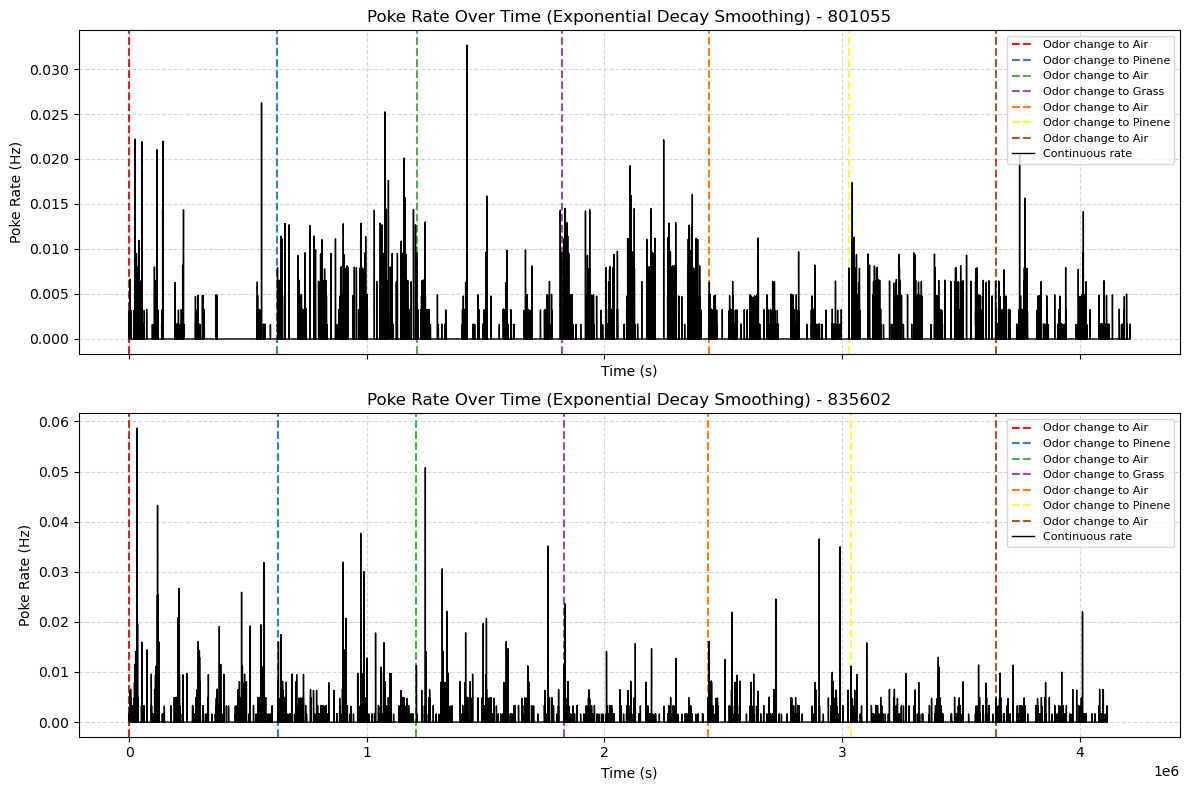

In [260]:
# Plot subplot timeseries of poke rate for each session, with vertical lines for odor changes
# color map for plotting odor changes dynamically
cmap = plt.get_cmap("Set1")
fig, axes = plt.subplots(
    len(poke_stats), 1, figsize=(12, 4 * len(poke_stats)), sharex=True
)
for i, ((subject, source_path), stats) in enumerate(poke_stats.items()):
    ax = axes[i] if len(poke_stats) > 1 else axes
    t_sample = stats["t"]
    r_poke = stats["poke_rate"]
    curr_odor_events = list(zip(stats["first_poke_t"], stats["odor_id"]))
    for j, (event_time, new_odor) in enumerate(curr_odor_events):
        ax.axvline(
            x=event_time - np.min(t_sample),
            color=cmap(j),
            linestyle="--",
            label=f"Odor change to {new_odor}",
        )
    ax.plot(t_sample, r_poke, color="black", lw=1, label="Continuous rate")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Poke Rate (Hz)")
    ax.set_title(f"Poke Rate Over Time (Exponential Decay Smoothing) - {subject}")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [261]:
# plot the spike rate over each chosen daily window
pre_w = 3600  # [s]
post_w = 3600  # [s]
pre_days = 3  # days before the odor change
post_days = 1  # days after odor change


# Function to extract poke rates in windows around odor changes
def extract_poke_rate_windows(
    poke_stats: Dict[Tuple[str, str], Dict[str, Any]],
    pre_w: float = 3600,
    post_w: float = 3600,
    pre_days: int = 3,
    post_days: int = 1,
) -> Dict[Tuple[str, str], Dict[str, Any]]:
    """
    Extract poke rate windows around odor change events.

    Parameters
    ----------
    poke_stats : dict
        Dictionary from compute_poke_stats containing poke rates and event times.
    pre_w : float
        Time before odor change to include in window (seconds).
    post_w : float
        Time after odor change to include in window (seconds).
    pre_days : int
        Number of days before odor change to include in analysis.
    post_days : int
        Number of days after odor change to include in analysis.

    Returns
    -------
    dict
        Dictionary containing poke rate windows around odor change events.
    """
    windows = {}

    for (subject, source_path), stats in poke_stats.items():
        t_sample = stats["t"]
        r_poke = stats["poke_rate"]
        odor_changes = list(zip(stats["first_poke_t"], stats["odor_id"]))

        for i, (event_time, new_odor) in enumerate(
            odor_changes[1:]
        ):  # Skip first change if it's the initial condition
            for day in range(-pre_days, post_days + 1):
                # Define window around odor change
                start_time = (event_time + (day * 24 * 3600)) - pre_w
                end_time = (event_time + (day * 24 * 3600)) + post_w
                _, prev_odor = odor_changes[i]

                # Extract poke rate in this window
                mask = (t_sample >= start_time) & (t_sample <= end_time)
                t_window = t_sample[mask] - (
                    event_time + day * 24 * 3600
                )  # Align to odor change
                r_window = r_poke[mask]

                windows[(subject, source_path, f"odor_change_{i}", f"day_{day}")] = {
                    "t_window": t_window,
                    "r_window": r_window,
                    "event_time": event_time,
                    "new_odor": new_odor,
                    "prev_odor": prev_odor,  # Could be filled in if needed
                }

    return windows

In [262]:
# Get poke rates around window
windowed_poke_rates = extract_poke_rate_windows(
    poke_stats, pre_w=3600, post_w=3600, pre_days=pre_days, post_days=post_days
)

In [263]:
windowed_poke_rates

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-3'): {'t_window': array([-3583.87497568, -3553.87497568, -3523.87497568, -3493.87497568,
         -3463.87497568, -3433.87497568, -3403.87497568, -3373.87497568,
         -3343.87497568, -3313.87497568, -3283.87497568, -3253.87497568,
         -3223.87497568, -3193.87497568, -3163.87497568, -3133.87497568,
         -3103.87497568, -3073.87497568, -3043.87497568, -3013.87497568,
         -2983.87497568, -2953.87497568, -2923.87497568, -2893.87497568,
         -2863.87497568, -2833.87497568, -2803.87497568, -2773.87497568,
         -2743.87497568, -2713.87497568, -2683.87497568, -2653.87497568,
         -2623.87497568, -2593.87497568, -2563.87497568, -2533.87497568,
         -2503.87497568, -2473.87497568, -2443.87497568, -2413.87497568,
         -2383.87497568, -2353.87497568, -2323.87497568, -2293.87497568,
         -2263.87497568, -2233.87497568,

In [264]:
def build_day_legend(pre_days, post_days, cmap_name="viridis"):
    cmap = cm.get_cmap(cmap_name)
    days = list(range(-pre_days, post_days + 1))

    # Normalize colors excluding day 0
    nonzero_days = [d for d in days if d != 0]
    color_map = dict(zip(nonzero_days, cmap(np.linspace(0, 1, len(nonzero_days)))))

    handles = []

    for d in days:
        if d == 0:
            handles.append(
                mlines.Line2D(
                    [],
                    [],
                    color="black",
                    linewidth=3,
                    label="Day 0",
                )
            )
        else:
            handles.append(
                mlines.Line2D(
                    [],
                    [],
                    color=color_map[d],
                    linewidth=1.5,
                    alpha=0.8,
                    label=f"Day {d}",
                )
            )
    return handles

C:\Users\brandon.pratt\AppData\Local\Temp\ipykernel_28468\2980100977.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")
C:\Users\brandon.pratt\AppData\Local\Temp\ipykernel_28468\49680508.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


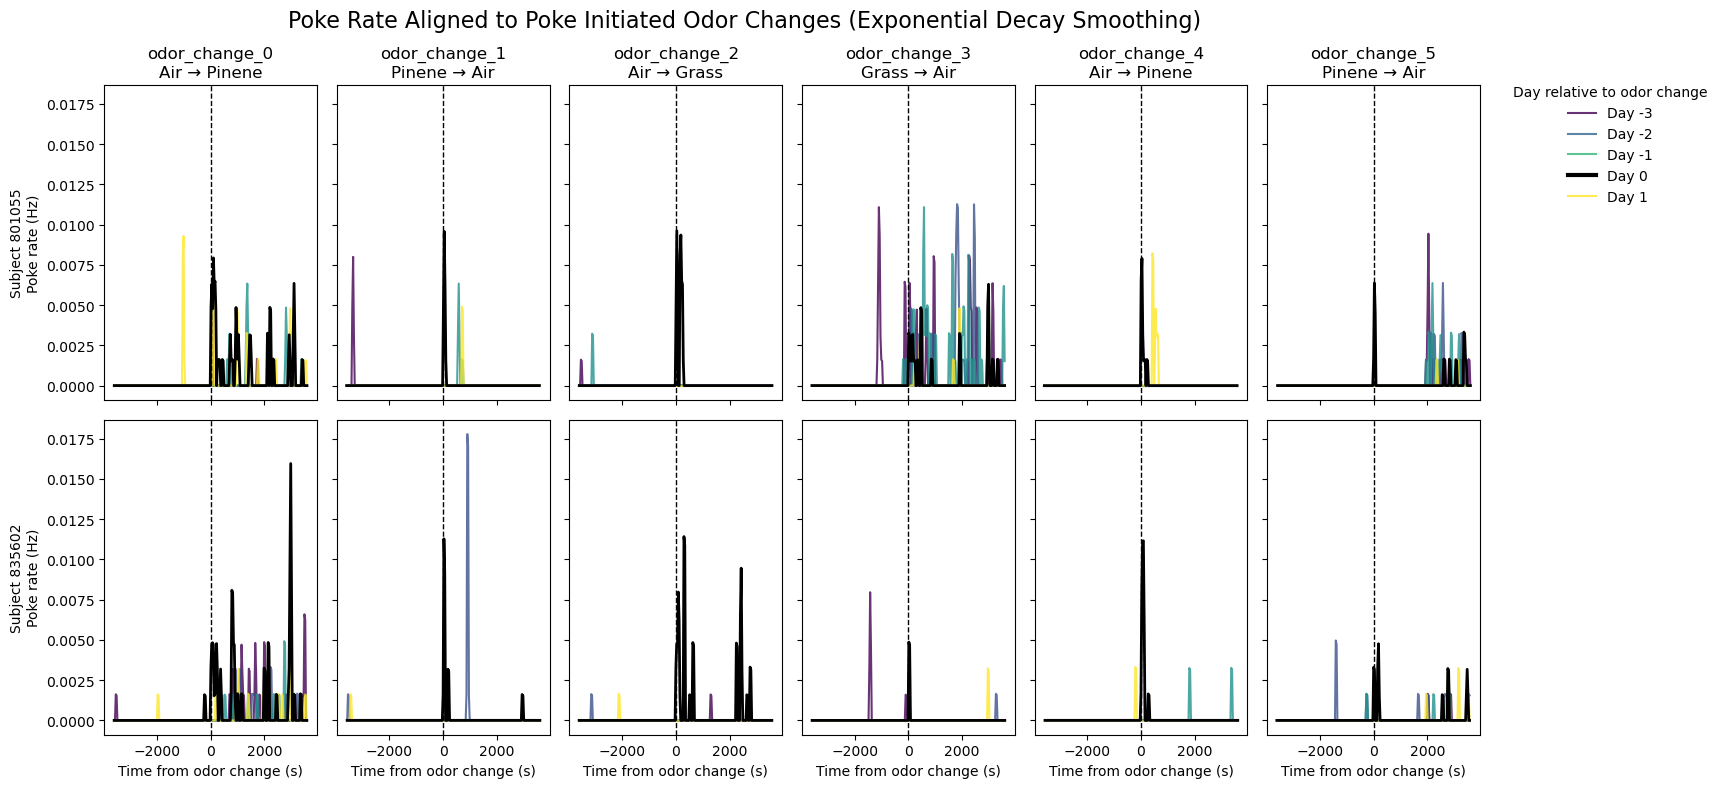

In [267]:
# plot the poke rate for each window of a given odor change per subject/session
# columns: odor change, row: subject/session, each day is a different color line within a panel


def plot_multiday_poke_rate_windows(windows, pre_days=pre_days, post_days=post_days):
    """
    Plot poke rate windows.
    Rows = subject/session
    Columns = odor change
    Lines = days (color-coded)
    """

    # ---- Reorganize data ----
    grouped = defaultdict(lambda: defaultdict(list))

    for (subject, source_path, odor_change, day), data in windows.items():
        session_key = (subject, source_path)
        grouped[session_key][odor_change].append((day, data))

    sessions = list(grouped.keys())
    odor_changes = sorted({oc for s in grouped.values() for oc in s.keys()})

    n_rows = len(sessions)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    cmap = get_cmap("viridis")

    # ---- Plot ----
    for r, session in enumerate(sessions):
        subject, source_path = session

        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in grouped[session]:
                ax.axis("off")
                continue

            entries = grouped[session][odor_change]

            # Sort days numerically
            entries.sort(key=lambda x: int(x[0].split("_")[1]))

            days = [int(day.split("_")[1]) for day, _ in entries]
            day_norm = np.linspace(0, 1, len(days))

            for (day, data), color in zip(entries, cmap(day_norm)):
                day_num = int(day.split("_")[1])

                if day_num == 0:
                    ax.plot(
                        data["t_window"],
                        data["r_window"],
                        color="black",
                        linewidth=2,
                        zorder=10,
                        label="Day 0",
                    )
                else:
                    ax.plot(
                        data["t_window"],
                        data["r_window"],
                        color=color,
                        linewidth=1.5,
                        alpha=0.8,
                        label=day,
                    )

            ax.axvline(0, color="k", linestyle="--", linewidth=1)

            if r == 0:
                ax.set_title(f"{odor_change}\n{data['prev_odor']} → {data['new_odor']}")

            if c == 0:
                ax.set_ylabel(f"Subject {subject}\nPoke rate (Hz)")

            if r == n_rows - 1:
                ax.set_xlabel("Time from odor change (s)")

    # ---- Legend ----
    handles = build_day_legend(pre_days=abs(pre_days), post_days=post_days)

    fig.legend(
        handles=handles,
        title="Day relative to odor change",
        loc="upper right",
        bbox_to_anchor=(1.15, 0.9),
        frameon=False,
    )

    fig.tight_layout()
    return fig


fig = plot_multiday_poke_rate_windows(windowed_poke_rates)
fig.suptitle(
    "Poke Rate Aligned to Poke Initiated Odor Changes (Exponential Decay Smoothing)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(result_dir.joinpath("poke_rate_windows.png"), dpi=300, bbox_inches="tight")
plt.show()


In [317]:
poke_stats

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv'): {'t': array([1.00479126e-02, 3.00100479e+01, 6.00100479e+01, ...,
         4.21176001e+06, 4.21179001e+06, 4.21182001e+06]),
  'poke_rate': array([0.00166667, 0.00158538, 0.        , ..., 0.        , 0.        ,
         0.        ]),
  'poke_events': array([1.00479126e-02, 2.30428736e+02, 3.31759680e+02, ...,
         4.21169701e+06, 4.21183093e+06, 4.21183348e+06]),
  'poke_durations': array([0.27660799, 0.50105619, 0.38211203, ..., 0.29350376, 0.16691208,
         0.12799978]),
  'odor_id': ['Air', 'Pinene', 'Air', 'Grass', 'Air', 'Pinene', 'Air'],
  'first_poke_t': [0.01004791259765625,
   624163.8850235939,
   1210071.9658875465,
   1820301.669599533,
   2438658.824511528,
   3028975.077152729,
   3646231.2347836494],
  'odor_switch_t': [599591.3093757629,
   1205951.309375763,
   1814531.309375763,
   2422211.309375763,
   3024131.309375763,
   3633311.309375763]},
 

In [ ]:
def extract_poke_rate_relative_to_odor_switch(
    poke_stats: Dict[Tuple[str, str], Dict[str, Any]],
    pre_days: int = 3,
    pre_w: float = 3600,
    post_w: float = 3600,
) -> Dict[Tuple[str, str], Dict[str, Any]]:
    """
    Extract poke rate aligned to the second poke after an odor switch.
    Computes a time-resolved baseline mean and 95% CI across the
    previous `pre_days` baseline days.

    Returns
    -------
    dict
        Dictionary containing:
        - per-day aligned poke rate windows
        - baseline time-series mean and 95% CI across days
    """

    odor_switch_aligned: Dict[Tuple[str, str, str, str], Dict[str, Any]] = {}

    for (subject, source_path), stats in poke_stats.items():
        t_sample = stats["t"]
        r_poke = stats["poke_rate"]
        poke_events = stats["poke_events"]
        odor_changes = list(zip(stats["odor_switch_t"], stats["odor_id"][1::]))

        for i, (event_time, new_odor) in enumerate(odor_changes):
            baseline_r_windows = []
            baseline_t_windows = []

            # -------------------------
            # Baseline days loop
            # -------------------------
            for day in range(-pre_days, 1):
                start_time = event_time + day * 24 * 3600
                poke_after = poke_events[poke_events > start_time]

                if len(poke_after) < 2:
                    continue

                # Align to second poke after switch
                second_poke_time = poke_after[1]

                w_start = second_poke_time - pre_w
                w_end = second_poke_time + post_w

                mask = (t_sample >= w_start) & (t_sample <= w_end)
                r_window = r_poke[mask]
                t_window = t_sample[mask] - second_poke_time

                if r_window.size == 0:
                    continue

                if day < 0:
                    baseline_r_windows.append(r_window)
                    baseline_t_windows.append(t_window)

                # Store individual baseline day window
                odor_switch_aligned[
                    (subject, source_path, f"odor_change_{i}", f"day_{day}")
                ] = {
                    "t_window": t_window,
                    "r_window": r_window,
                    "second_poke_time": second_poke_time,
                    "new_odor": new_odor,
                    "prev_odor": stats["odor_id"][i],
                }
                # print(stats["odor_id"][i])
                # print(new_odor)

            # -------------------------
            # Baseline time-series mean + CI
            # -------------------------
            if len(baseline_r_windows) >= 2:
                # Ensure common length
                min_len = min(len(r) for r in baseline_r_windows)

                r_stack = np.vstack(
                    [r[:min_len] for r in baseline_r_windows]
                )  # shape: (n_days, n_timepoints)

                t_baseline = baseline_t_windows[0][:min_len]

                mean_rate = r_stack.mean(axis=0)

                n_days = r_stack.shape[0]
                sem = r_stack.std(axis=0, ddof=1) / np.sqrt(n_days)
                tcrit = t.ppf(0.975, df=n_days - 1)
                ci_95 = tcrit * sem

            else:
                t_baseline = None
                mean_rate = None
                ci_95 = None
                n_days = len(baseline_r_windows)

            # Store baseline time-series summary
            odor_switch_aligned[(subject, source_path, "baseline_timeseries")] = {
                "t_window": t_baseline,
                "mean_rate": mean_rate,
                "ci_95": ci_95,
                "n_days_used": n_days,
                "new_odor": new_odor,
                "prev_odor": stats["odor_id"][i],
            }

    return odor_switch_aligned

In [333]:
# Get poke rates around second poke after odor switch with baseline statistics
odor_switch_aligned_rates = extract_poke_rate_relative_to_odor_switch(
    poke_stats, pre_w=3600, post_w=3600, pre_days=pre_days
)
odor_switch_aligned_rates

Air
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Air
Air
Grass
Air
Grass
Air
Grass
Air
Grass
Grass
Air
Grass
Air
Grass
Air
Grass
Air
Air
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Air
Air
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Air
Air
Grass
Air
Grass
Air
Grass
Air
Grass
Grass
Air
Grass
Air
Grass
Air
Grass
Air
Air
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Pinene
Air
Pinene
Air
Pinene
Air
Pinene
Air


{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-3'): {'t_window': array([-3588.50166368, -3558.50166368, -3528.50166368, -3498.50166368,
         -3468.50166368, -3438.50166368, -3408.50166368, -3378.50166368,
         -3348.50166368, -3318.50166368, -3288.50166368, -3258.50166368,
         -3228.50166368, -3198.50166368, -3168.50166368, -3138.50166368,
         -3108.50166368, -3078.50166368, -3048.50166368, -3018.50166368,
         -2988.50166368, -2958.50166368, -2928.50166368, -2898.50166368,
         -2868.50166368, -2838.50166368, -2808.50166368, -2778.50166368,
         -2748.50166368, -2718.50166368, -2688.50166368, -2658.50166368,
         -2628.50166368, -2598.50166368, -2568.50166368, -2538.50166368,
         -2508.50166368, -2478.50166368, -2448.50166368, -2418.50166368,
         -2388.50166368, -2358.50166368, -2328.50166368, -2298.50166368,
         -2268.50166368, -2238.50166368,

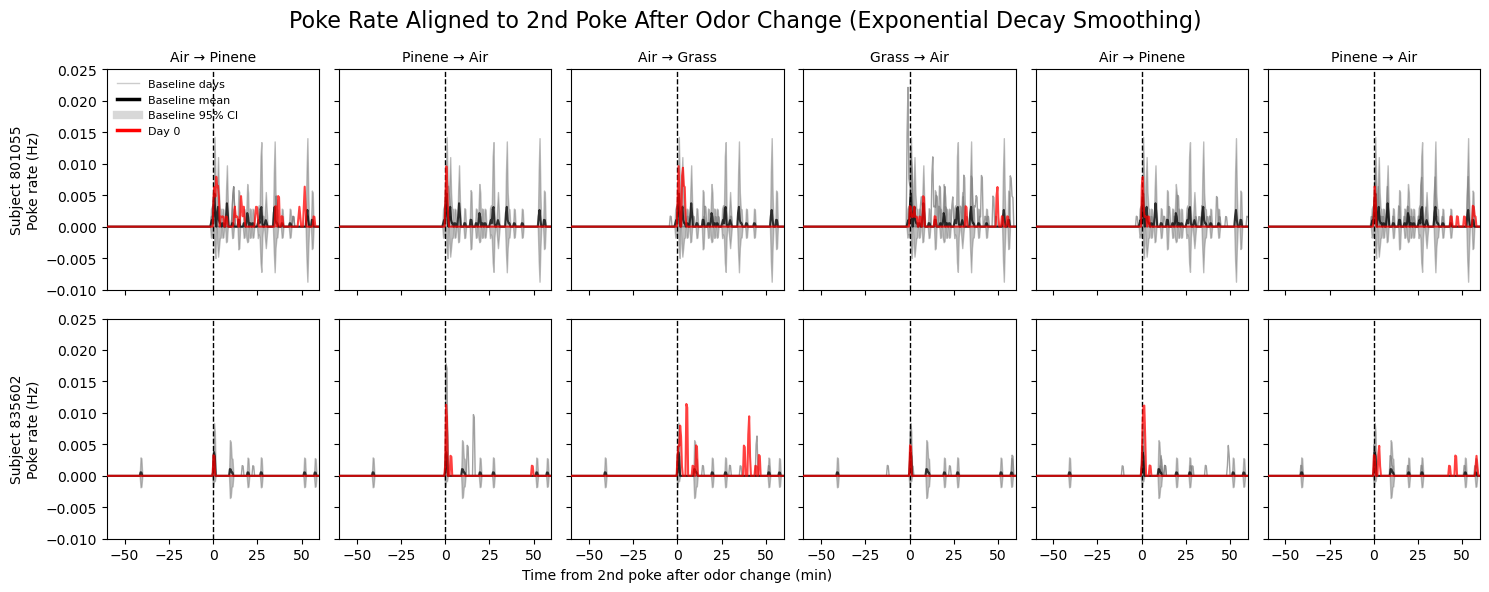

In [ ]:
def plot_odor_switch_aligned_poke_rates(
    odor_switch_aligned,
    pre_days: int = 3,
    time_unit: str = "seconds",  # "seconds", "minutes", or "hours"
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Gray thin lines: baseline days (day -pre_days ... day -1)
      - Black thick line: baseline mean (time series)
      - Gray shaded band: baseline 95% CI
      - Red thick line: day 0

    Parameters
    ----------
    time_unit : {"seconds", "minutes", "hours"}
        Unit to display on the x-axis
    """

    import matplotlib.pyplot as plt
    from collections import defaultdict
    import numpy as np

    # -------------------------
    # Time unit handling
    # -------------------------
    unit_scale = {
        "seconds": 1.0,
        "minutes": 60.0,
        "hours": 3600.0,
    }

    if time_unit not in unit_scale:
        raise ValueError("time_unit must be 'seconds', 'minutes', or 'hours'")

    scale = unit_scale[time_unit]
    time_label = {
        "seconds": "s",
        "minutes": "min",
        "hours": "h",
    }[time_unit]

    # Axis limits (defined in seconds → converted)
    xlim_seconds = (-3600, 3600)
    xlim = (xlim_seconds[0] / scale, xlim_seconds[1] / scale)

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(lambda: defaultdict(dict))
    baseline_by_session = {}

    for key, data in odor_switch_aligned.items():
        # Baseline time series stored once per session
        if len(key) == 3 and key[2] == "baseline_timeseries":
            subject, source_path, _ = key
            baseline_by_session[(subject, source_path)] = data
        else:
            subject, source_path, odor_change, day = key
            sessions[(subject, source_path)][odor_change][day] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, session in enumerate(session_keys):
        subject, source_path = session
        baseline = baseline_by_session.get(session)

        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[session]:
                ax.axis("off")
                continue

            entries = sessions[session][odor_change]

            # ---- Baseline days (gray) ----
            for day in range(-pre_days, 0):
                label = f"day_{day}"
                if label in entries:
                    ax.plot(
                        entries[label]["t_window"] / scale,
                        entries[label]["r_window"],
                        color="gray",
                        alpha=0.75,
                        linewidth=1,
                        zorder=1,
                    )

            # ---- Baseline mean + CI ----
            if baseline is not None and baseline["mean_rate"] is not None:
                t = baseline["t_window"] / scale
                mean = baseline["mean_rate"]
                ci = baseline["ci_95"]

                ax.fill_between(
                    t,
                    mean - ci,
                    mean + ci,
                    color="gray",
                    alpha=0.5,
                    zorder=2,
                )

                ax.plot(
                    t,
                    mean,
                    color="black",
                    linewidth=1.5,
                    zorder=3,
                    alpha=0.75,
                )

            # ---- Day 0 (red) ----
            if "day_0" in entries:
                ax.plot(
                    entries["day_0"]["t_window"] / scale,
                    entries["day_0"]["r_window"],
                    color="red",
                    linewidth=1.5,
                    zorder=4,
                    alpha=0.75,
                )

            # ---- Axes formatting ----
            ax.axvline(0, color="k", linestyle="--", linewidth=1)
            ax.set_xlim(*xlim)
            ax.set_ylim(-0.01, 0.025)

            # ---- Column titles ----
            if r == 0:
                example_entry = entries.get("day_0", next(iter(entries.values())))
                prev_odor = example_entry.get("prev_odor", "?")
                new_odor = example_entry.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(f"Subject {subject}\nPoke rate (Hz)")

            if r == n_rows - 1 and c == 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )

    # -------------------------
    # Legend
    # -------------------------
    legend_handles = [
        plt.Line2D([], [], color="gray", linewidth=1, alpha=0.4, label="Baseline days"),
        plt.Line2D([], [], color="black", linewidth=2.5, label="Baseline mean"),
        plt.Line2D(
            [], [], color="gray", linewidth=6, alpha=0.3, label="Baseline 95% CI"
        ),
        plt.Line2D([], [], color="red", linewidth=2.5, label="Day 0"),
    ]

    axes[0, 0].legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    fig.tight_layout()
    return fig


# create the figure
fig = plot_odor_switch_aligned_poke_rates(
    odor_switch_aligned_rates, pre_days=3, time_unit="minutes"
)

fig.suptitle(
    "Poke Rate Aligned to 2nd Poke After Odor Change (Exponential Decay Smoothing)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_odor_switch_aligned.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:
def compute_fold_change_day0_vs_baseline(
    odor_switch_aligned,
    pre_days: int = 3,
    min_baseline_rate: float = 1e-4,
):
    """
    Compute time-resolved baseline comparison between day 0 and baseline days.

    Stored per odor change as a SINGLE dictionary entry containing:
      - mean difference in rate (Δ-rate)
      - 95% CI of the difference across baseline days
      - z-score relative to baseline variability

    Statistics are computed ACROSS BASELINE DAYS at EACH TIMEPOINT.
    """

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(lambda: defaultdict(dict))
    for key, data in odor_switch_aligned.items():
        if len(key) == 4:
            subject, source_path, odor_change, label = key
            sessions[(subject, source_path)][odor_change][label] = data

    # Non-destructive copy
    results = dict(odor_switch_aligned)

    # -------------------------
    # Compute metrics
    # -------------------------
    for (subject, source_path), odor_changes in sessions.items():
        for odor_change, entries in odor_changes.items():
            if "day_0" not in entries:
                continue

            r0 = entries["day_0"]["r_window"]
            t0 = entries["day_0"]["t_window"]

            baseline_rates = []

            # Collect baseline rates
            for day in range(-pre_days, 0):
                label = f"day_{day}"
                if label not in entries:
                    continue

                r_base = entries[label]["r_window"]

                min_len = min(len(r0), len(r_base))
                if min_len == 0:
                    continue

                baseline_rates.append(r_base[:min_len])

            # Need at least 2 baseline days
            if len(baseline_rates) < 2:
                continue

            # Stack baseline rates: (n_days, n_timepoints)
            baseline_stack = np.vstack(baseline_rates)
            r0c = r0[: baseline_stack.shape[1]]

            n_days = baseline_stack.shape[0]

            # -------------------------
            # Baseline statistics
            # -------------------------
            baseline_mean = np.mean(baseline_stack, axis=0)
            baseline_std = np.std(baseline_stack, axis=0, ddof=1)

            # -------------------------
            # Option 1: Δ-rate
            # -------------------------
            diff_stack = r0c - baseline_stack
            mean_delta = np.mean(diff_stack, axis=0)

            sem_delta = np.std(diff_stack, axis=0, ddof=1) / np.sqrt(n_days)
            tcrit = t.ppf(0.975, n_days - 1)
            ci_95 = tcrit * sem_delta

            # -------------------------
            # Option 2: Z-score
            # -------------------------
            z = np.full_like(mean_delta, np.nan, dtype=float)
            valid = baseline_std > min_baseline_rate
            z[valid] = (r0c[valid] - baseline_mean[valid]) / baseline_std[valid]

            # -------------------------
            # Store as ONE entry
            # -------------------------
            results[
                (subject, source_path, odor_change, "baseline_difference_timeseries")
            ] = {
                "t_window": t0[: len(mean_delta)],
                "mean_delta": mean_delta,
                "ci_95": ci_95,
                "z_score": z,
                "n_days_used": n_days,
                "prev_odor": entries["day_0"]["prev_odor"],
                "new_odor": entries["day_0"]["new_odor"],
            }

    return results

In [374]:
# Compute the fold change time series
poke_rate_diff = compute_fold_change_day0_vs_baseline(
    odor_switch_aligned_rates,
    pre_days=3,
)
poke_rate_diff

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-3'): {'t_window': array([-3588.50166368, -3558.50166368, -3528.50166368, -3498.50166368,
         -3468.50166368, -3438.50166368, -3408.50166368, -3378.50166368,
         -3348.50166368, -3318.50166368, -3288.50166368, -3258.50166368,
         -3228.50166368, -3198.50166368, -3168.50166368, -3138.50166368,
         -3108.50166368, -3078.50166368, -3048.50166368, -3018.50166368,
         -2988.50166368, -2958.50166368, -2928.50166368, -2898.50166368,
         -2868.50166368, -2838.50166368, -2808.50166368, -2778.50166368,
         -2748.50166368, -2718.50166368, -2688.50166368, -2658.50166368,
         -2628.50166368, -2598.50166368, -2568.50166368, -2538.50166368,
         -2508.50166368, -2478.50166368, -2448.50166368, -2418.50166368,
         -2388.50166368, -2358.50166368, -2328.50166368, -2298.50166368,
         -2268.50166368, -2238.50166368,

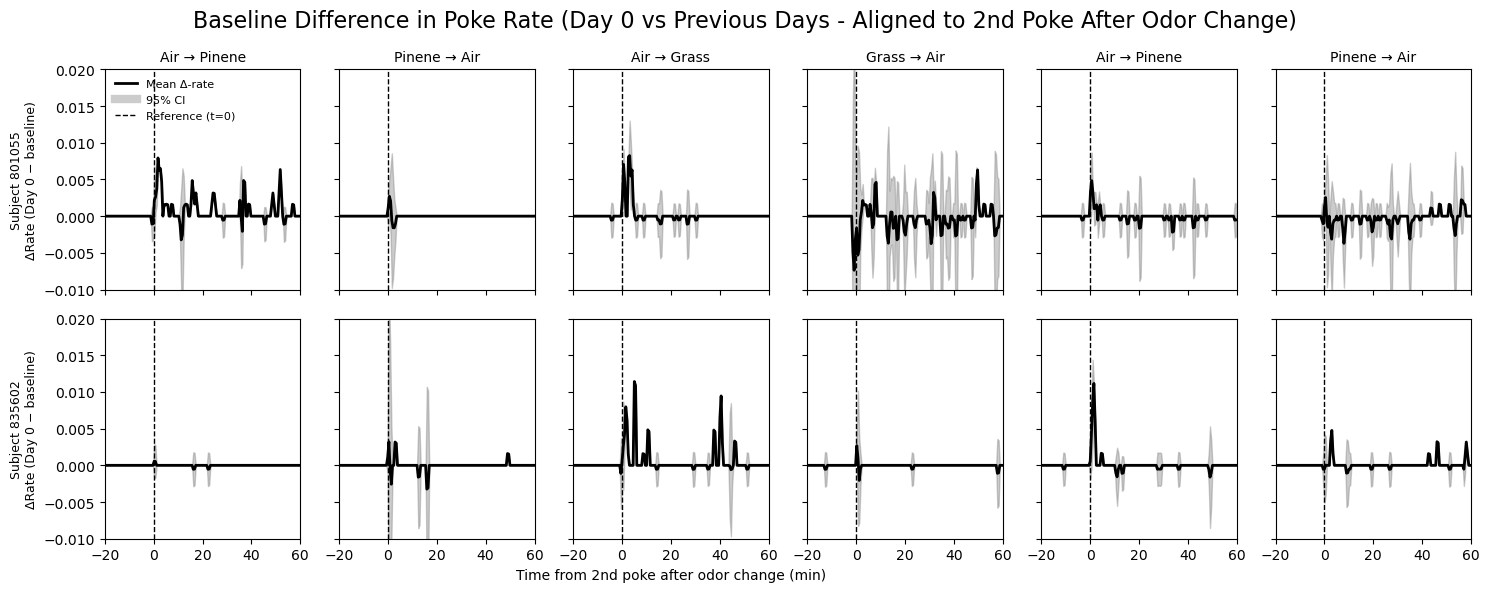

In [ ]:
def plot_odor_switch_aligned_rate_difference(
    odor_switch_with_fc,
    time_unit: str = "minutes",  # "seconds", "minutes", or "hours"
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Black thick line: mean Δ-rate (Day 0 - baseline)
      - Gray shaded band: 95% CI across baseline days
      - Vertical line at 0: odor-aligned reference

    Parameters
    ----------
    time_unit : {"seconds", "minutes", "hours"}
        Unit to display on the x-axis
    """

    # -------------------------
    # Time unit handling
    # -------------------------
    unit_scale = {
        "seconds": 1.0,
        "minutes": 60.0,
        "hours": 3600.0,
    }

    if time_unit not in unit_scale:
        raise ValueError("time_unit must be 'seconds', 'minutes', or 'hours'")

    scale = unit_scale[time_unit]
    time_label = {
        "seconds": "s",
        "minutes": "min",
        "hours": "h",
    }[time_unit]

    # Axis limits (in seconds → converted)
    xlim_seconds = (-1200, 3600)
    xlim = (xlim_seconds[0] / scale, xlim_seconds[1] / scale)

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)

    for key, data in odor_switch_with_fc.items():
        if len(key) == 4 and key[3] == "baseline_difference_timeseries":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, (subject, source_path) in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[(subject, source_path)]:
                ax.axis("off")
                continue

            fc = sessions[(subject, source_path)][odor_change]

            # Convert time axis
            t = fc["t_window"] / scale
            mean_fc = fc["mean_delta"]
            ci = fc["ci_95"]

            # ---- Mean + CI ----
            ax.fill_between(
                t,
                mean_fc - ci,
                mean_fc + ci,
                color="gray",
                alpha=0.4,
                zorder=1,
            )

            ax.plot(
                t,
                mean_fc,
                color="black",
                linewidth=2,
                zorder=2,
            )

            # ---- Reference lines ----
            ax.axvline(0, color="k", linestyle="--", linewidth=1)

            # ---- Axes formatting ----
            ax.set_xlim(*xlim)
            ax.set_ylim(-0.01, 0.02)

            # ---- Titles ----
            if r == 0:
                prev_odor = fc.get("prev_odor", "?")
                new_odor = fc.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(
                    f"Subject {subject}\nΔRate (Day 0 − baseline)",
                    fontsize=9,
                )

            if r == n_rows - 1 and c == 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )

    # -------------------------
    # Legend in upper-left subplot
    # -------------------------
    legend_handles = [
        plt.Line2D([], [], color="black", linewidth=2, label="Mean Δ-rate"),
        plt.Line2D([], [], color="gray", linewidth=6, alpha=0.4, label="95% CI"),
        plt.Line2D(
            [], [], color="black", linestyle="--", linewidth=1, label="Reference (t=0)"
        ),
    ]

    axes[0, 0].legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    fig.tight_layout()
    return fig


fig = plot_odor_switch_aligned_rate_difference(poke_rate_diff)
fig.suptitle(
    "Baseline Difference in Poke Rate (Day 0 vs Previous Days - Aligned to 2nd Poke After Odor Change)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_difference_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [ ]:
def raw_fold_change(poke_rate_day0, poke_rate_baseline, epsilon):
    """
    Raw ratio fold change, centered so that 0 = no change. Lower bound is -1. Range (-1, 0) indicates baseline greater than day 0, range (0, ∞) indicates day 0 greater than baseline.
    """
    return ((poke_rate_day0 + epsilon) / (poke_rate_baseline + epsilon)) - 1


def log_fold_change(poke_rate_day0, poke_rate_baseline, epsilon):
    """
    Log2 fold change, zero-centered and symmetric.
    """
    return np.log2((poke_rate_day0 + epsilon) / (poke_rate_baseline + epsilon))


def compute_fold_change_day0_vs_baseline_ratio(
    odor_switch_aligned,
    pre_days: int = 3,
    min_baseline_rate: float = 1e-4,
):
    """
    Compute time-resolved fold change between day 0 and EACH baseline day.

    - ε is estimated from the 5th percentile of all nonzero rates
    - Raw ratio fold change (centered at 0) is preserved
    - SPD is replaced by log-fold change
    """

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(lambda: defaultdict(dict))
    for key, data in odor_switch_aligned.items():
        if len(key) == 4:
            subject, source_path, odor_change, day = key
            sessions[(subject, source_path)][odor_change][day] = data

    results = dict(odor_switch_aligned)

    # -------------------------
    # Compute metrics
    # -------------------------
    for (subject, source_path), odor_changes in sessions.items():
        for odor_change, entries in odor_changes.items():
            if "day_0" not in entries:
                continue

            r0 = entries["day_0"]["r_window"]
            t0 = entries["day_0"]["t_window"]

            fold_change_days_raw = []
            fold_change_days_log = []

            # -------------------------
            # Estimate epsilon from ALL available rates
            # -------------------------
            all_rates = []

            all_rates.append(r0)

            for day in range(-pre_days, 0):
                label = f"day_{day}"
                if label in entries:
                    all_rates.append(entries[label]["r_window"])

            all_rates = np.concatenate(all_rates)
            nonzero = all_rates[all_rates > 0]

            if nonzero.size == 0:
                continue

            epsilon = np.percentile(nonzero, 5)

            # -------------------------
            # Compute fold change PER baseline day
            # -------------------------
            for day in range(-pre_days, 0):
                label = f"day_{day}"
                if label not in entries:
                    continue

                r_base = entries[label]["r_window"]

                n = min(len(r0), len(r_base))
                if n == 0:
                    continue

                raw_fc_day = raw_fold_change(r0[:n], r_base[:n], epsilon)
                fold_change_days_raw.append(raw_fc_day)

                log_fc_day = log_fold_change(r0[:n], r_base[:n], epsilon)
                fold_change_days_log.append(log_fc_day)

            if len(fold_change_days_raw) < 2:
                continue

            # -------------------------
            # Stack fold changes (day × time)
            # -------------------------
            fc_stack_raw = np.vstack(fold_change_days_raw)
            fc_stack_log = np.vstack(fold_change_days_log)

            n_days, n_time = fc_stack_raw.shape

            # -------------------------
            # Mean + CI across baseline days
            # -------------------------
            mean_fc_raw = np.mean(fc_stack_raw, axis=0)
            std_fc_raw = np.std(fc_stack_raw, axis=0, ddof=1)
            sem_fc_raw = std_fc_raw / np.sqrt(n_days)
            ci_95_raw = 1.960 * sem_fc_raw

            mean_fc_log = np.mean(fc_stack_log, axis=0)
            std_fc_log = np.std(fc_stack_log, axis=0, ddof=1)
            sem_fc_log = std_fc_log / np.sqrt(n_days)
            ci_95_log = 1.960 * sem_fc_log

            results[
                (subject, source_path, odor_change, "baseline_fold_change_timeseries")
            ] = {
                "t_window": t0[:n_time],
                "mean_fc_ratio": mean_fc_raw,
                "ci_95_ratio": ci_95_raw,
                "mean_fc_log": mean_fc_log,
                "ci_95_log": ci_95_log,
                "epsilon_used": epsilon,
                "n_days_used": n_days,
                "prev_odor": entries["day_0"]["prev_odor"],
                "new_odor": entries["day_0"]["new_odor"],
            }

    return results

In [548]:
# create fold change dictrionary
poke_rate_fc = compute_fold_change_day0_vs_baseline_ratio(
    odor_switch_aligned_rates,
    pre_days=3,
)
poke_rate_fc

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-3'): {'t_window': array([-3588.50166368, -3558.50166368, -3528.50166368, -3498.50166368,
         -3468.50166368, -3438.50166368, -3408.50166368, -3378.50166368,
         -3348.50166368, -3318.50166368, -3288.50166368, -3258.50166368,
         -3228.50166368, -3198.50166368, -3168.50166368, -3138.50166368,
         -3108.50166368, -3078.50166368, -3048.50166368, -3018.50166368,
         -2988.50166368, -2958.50166368, -2928.50166368, -2898.50166368,
         -2868.50166368, -2838.50166368, -2808.50166368, -2778.50166368,
         -2748.50166368, -2718.50166368, -2688.50166368, -2658.50166368,
         -2628.50166368, -2598.50166368, -2568.50166368, -2538.50166368,
         -2508.50166368, -2478.50166368, -2448.50166368, -2418.50166368,
         -2388.50166368, -2358.50166368, -2328.50166368, -2298.50166368,
         -2268.50166368, -2238.50166368,

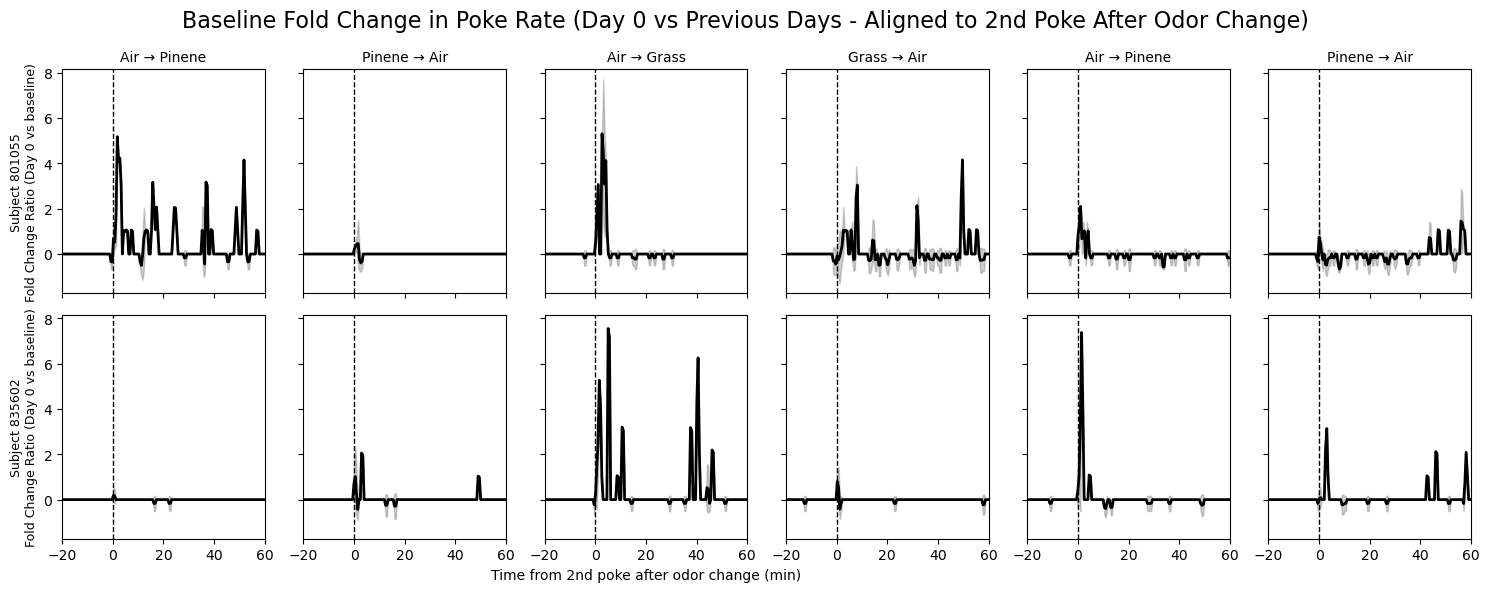

In [549]:
# Plot fold change time series for raw and spd fold change on different figures
def plot_odor_switch_aligned_fold_change(
    odor_switch_fc,
    time_unit: str = "minutes",  # "seconds", "minutes", or "hours"
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Black thick line: mean fold change ratio (Day 0 vs baseline)
      - Gray shaded band: 95% CI across baseline days
      - Vertical line at 0: odor-aligned reference

    Parameters
    ----------
    time_unit : {"seconds", "minutes", "hours"}
        Unit to display on the x-axis
    """

    # -------------------------
    # Time unit handling
    # -------------------------
    unit_scale = {
        "seconds": 1.0,
        "minutes": 60.0,
        "hours": 3600.0,
    }

    if time_unit not in unit_scale:
        raise ValueError("time_unit must be 'seconds', 'minutes', or 'hours'")

    scale = unit_scale[time_unit]
    time_label = {
        "seconds": "s",
        "minutes": "min",
        "hours": "h",
    }[time_unit]

    # Axis limits (in seconds → converted)
    xlim_seconds = (-1200, 3600)
    xlim = (xlim_seconds[0] / scale, xlim_seconds[1] / scale)

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)

    for key, data in odor_switch_fc.items():
        if len(key) == 4 and key[3] == "baseline_fold_change_timeseries":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, (subject, source_path) in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[(subject, source_path)]:
                ax.axis("off")
                continue

            fc = sessions[(subject, source_path)][odor_change]

            # Convert time axis
            t = fc["t_window"] / scale
            mean_fc = fc["mean_fc_ratio"]
            ci = fc["ci_95_ratio"]

            # ---- Mean + CI ----
            ax.fill_between(
                t,
                mean_fc - ci,
                mean_fc + ci,
                color="gray",
                alpha=0.4,
                zorder=1,
            )

            ax.plot(
                t,
                mean_fc,
                color="black",
                linewidth=2,
                zorder=2,
            )

            # ---- Reference lines ----
            ax.axvline(0, color="k", linestyle="--", linewidth=1)

            # ---- Axes formatting ----
            ax.set_xlim(*xlim)
            # ax.set_ylim(-0.5, 1.0)

            # ---- Titles ----
            if r == 0:
                prev_odor = fc.get("prev_odor", "?")
                new_odor = fc.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(
                    f"Subject {subject}\nFold Change Ratio (Day 0 vs baseline)",
                    fontsize=9,
                )

            if r == n_rows - 1 and c == 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )
    # -------------------------
    plt.tight_layout()
    return fig


fig = plot_odor_switch_aligned_fold_change(poke_rate_fc)
fig.suptitle(
    "Baseline Fold Change in Poke Rate (Day 0 vs Previous Days - Aligned to 2nd Poke After Odor Change)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_fold_change_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

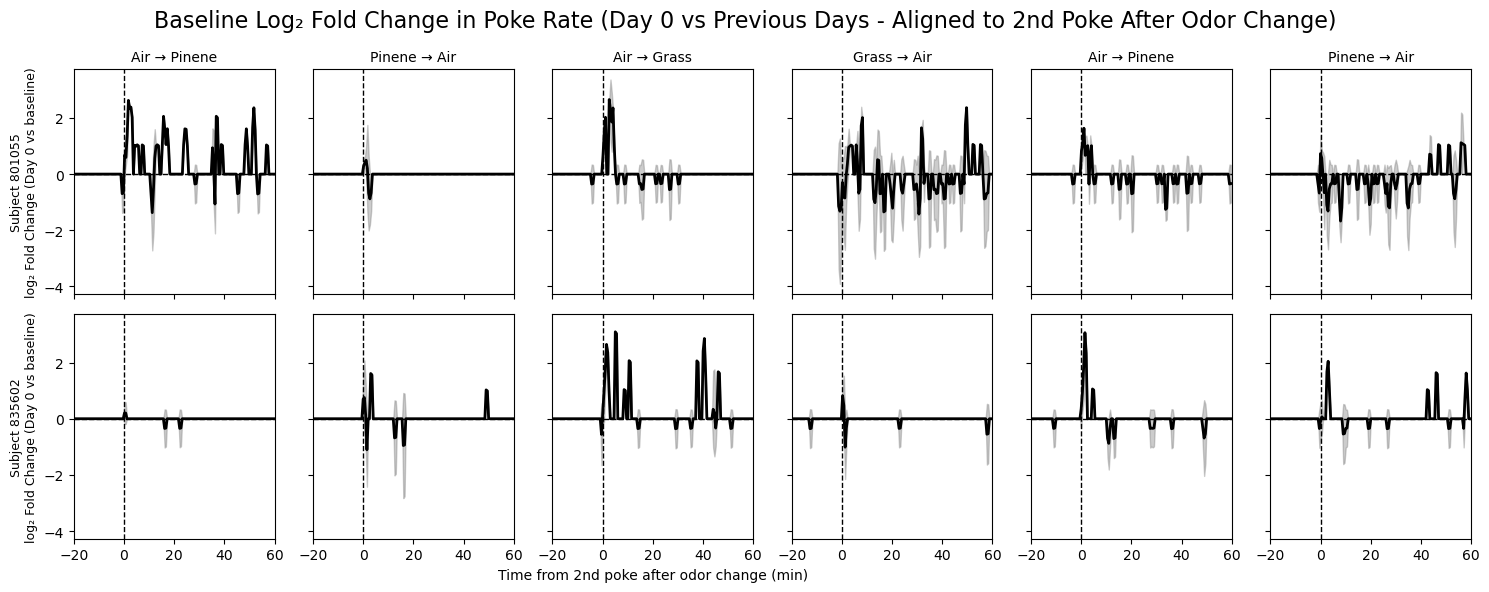

In [ ]:
def plot_odor_switch_aligned_fold_change_log(
    odor_switch_fc,
    time_unit: str = "minutes",  # "seconds", "minutes", or "hours"
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Black thick line: mean log2 fold change (Day 0 vs baseline)
      - Gray shaded band: 95% CI across baseline days
      - Vertical line at 0: odor-aligned reference
      - Horizontal line at 0: no change

    Parameters
    ----------
    time_unit : {"seconds", "minutes", "hours"}
        Unit to display on the x-axis
    """

    import matplotlib.pyplot as plt
    from collections import defaultdict
    import numpy as np

    # -------------------------
    # Time unit handling
    # -------------------------
    unit_scale = {
        "seconds": 1.0,
        "minutes": 60.0,
        "hours": 3600.0,
    }

    if time_unit not in unit_scale:
        raise ValueError("time_unit must be 'seconds', 'minutes', or 'hours'")

    scale = unit_scale[time_unit]
    time_label = {
        "seconds": "s",
        "minutes": "min",
        "hours": "h",
    }[time_unit]

    # Axis limits (in seconds → converted)
    xlim_seconds = (-1200, 3600)
    xlim = (xlim_seconds[0] / scale, xlim_seconds[1] / scale)

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)

    for key, data in odor_switch_fc.items():
        if len(key) == 4 and key[3] == "baseline_fold_change_timeseries":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, (subject, source_path) in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[(subject, source_path)]:
                ax.axis("off")
                continue

            fc = sessions[(subject, source_path)][odor_change]

            # Convert time axis
            t = fc["t_window"] / scale
            mean_fc = fc["mean_fc_log"]
            ci = fc["ci_95_log"]

            # ---- Mean + CI ----
            ax.fill_between(
                t,
                mean_fc - ci,
                mean_fc + ci,
                color="gray",
                alpha=0.4,
                zorder=1,
            )

            ax.plot(
                t,
                mean_fc,
                color="black",
                linewidth=2,
                zorder=2,
            )

            # ---- Reference lines ----
            ax.axvline(0, color="k", linestyle="--", linewidth=1)
            ax.axhline(0, color="k", linestyle="--", linewidth=1)

            # ---- Axes formatting ----
            ax.set_xlim(*xlim)
            # Optional: enforce symmetric log-FC limits
            # ax.set_ylim(-2, 2)

            # ---- Titles ----
            if r == 0:
                prev_odor = fc.get("prev_odor", "?")
                new_odor = fc.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(
                    f"Subject {subject}\nlog₂ Fold Change (Day 0 vs baseline)",
                    fontsize=9,
                )

            if r == n_rows - 1 and c == 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )

    plt.tight_layout()
    return fig


fig = plot_odor_switch_aligned_fold_change_log(poke_rate_fc)
fig.suptitle(
    "Baseline Log₂ Fold Change in Poke Rate (Day 0 vs Previous Days - Aligned to 2nd Poke After Odor Change)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_fold_change_log_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

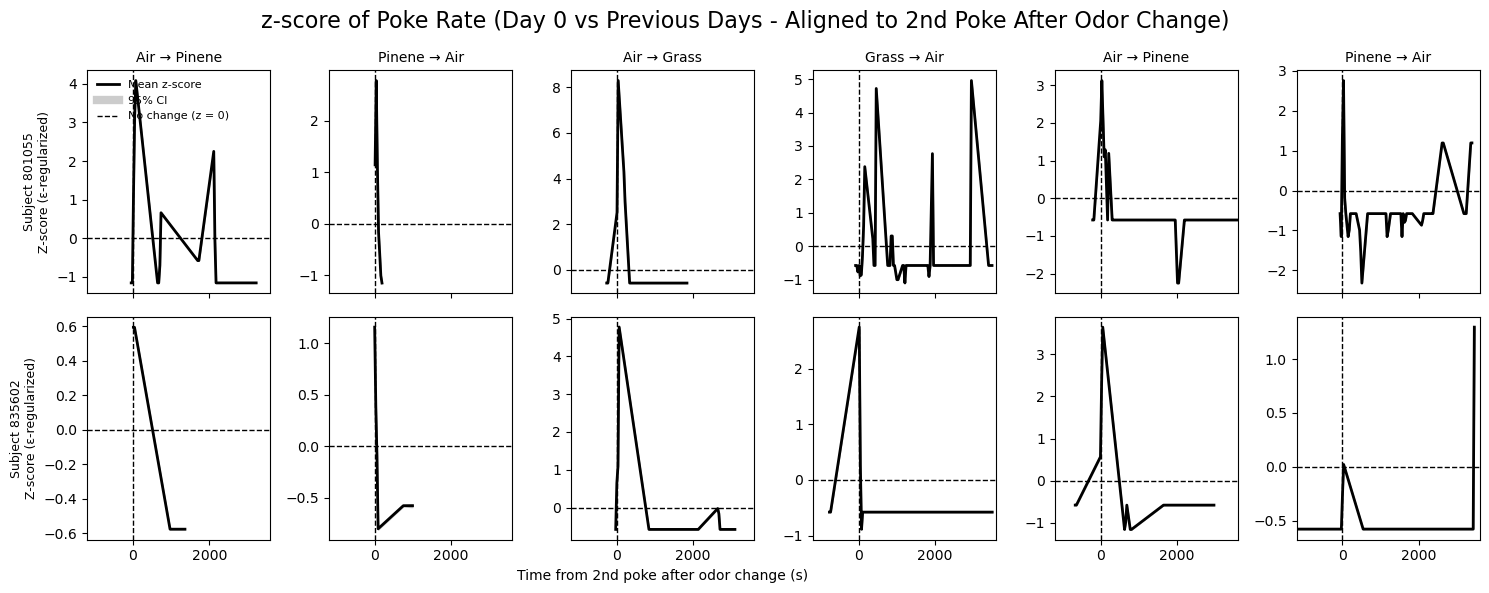

In [552]:
def plot_odor_switch_aligned_zscore(
    odor_switch_with_fc,
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Black thick line: ε-regularized z-score (Day 0 vs baseline)
      - Gray shaded band: 95% CI across baseline days
      - Horizontal line at 0: no change
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from collections import defaultdict

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)

    for key, data in odor_switch_with_fc.items():
        if len(key) == 4 and key[3] == "baseline_difference_timeseries":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, (subject, source_path) in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[(subject, source_path)]:
                ax.axis("off")
                continue

            data = sessions[(subject, source_path)][odor_change]

            t = data["t_window"]
            z = data["z_score"]
            ci = data["ci_95"]

            # -------------------------
            # ε-regularization (if metadata is available)
            # -------------------------
            baseline_std = data.get("baseline_std", None)
            epsilon = data.get("epsilon_used", None)

            if baseline_std is not None and epsilon is not None:
                scale = baseline_std / (baseline_std + epsilon)
                z = z * scale
                ci = ci * scale

            # Mask invalid values
            valid = ~np.isnan(z)

            # ---- Mean + CI ----
            ax.fill_between(
                t[valid],
                z[valid] - ci[valid],
                z[valid] + ci[valid],
                color="gray",
                alpha=0.4,
                zorder=1,
            )

            ax.plot(
                t[valid],
                z[valid],
                color="black",
                linewidth=2,
                zorder=2,
            )

            # ---- Reference lines ----
            ax.axhline(0, color="k", linestyle="--", linewidth=1)
            ax.axvline(0, color="k", linestyle="--", linewidth=1)

            # ---- Axes formatting ----
            ax.set_xlim(-1200, 3600)

            # ---- Titles ----
            if r == 0:
                prev_odor = data.get("prev_odor", "?")
                new_odor = data.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(
                    f"Subject {subject}\nZ-score (ε-regularized)",
                    fontsize=9,
                )

            if r == n_rows - 1 and c == 2:
                ax.set_xlabel(
                    "Time from 2nd poke after odor change (s)",
                    fontsize=10,
                )

    # -------------------------
    # Legend
    # -------------------------
    legend_handles = [
        plt.Line2D([], [], color="black", linewidth=2, label="Mean z-score"),
        plt.Line2D([], [], color="gray", linewidth=6, alpha=0.4, label="95% CI"),
        plt.Line2D(
            [],
            [],
            color="black",
            linestyle="--",
            linewidth=1,
            label="No change (z = 0)",
        ),
    ]

    axes[0, 0].legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    fig.tight_layout()
    return fig


fig = plot_odor_switch_aligned_zscore(poke_rate_diff)
fig.suptitle(
    "z-score of Poke Rate (Day 0 vs Previous Days - Aligned to 2nd Poke After Odor Change)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_zscore_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Null model of poke rates
- Find first poke after a long IPI ~ Mouse leaving and coming back. 
- Allow for time of day (beginning and end) inputs
- Should be based on burst statistics
- Look at circadian influnences and normalize to that
- Quantify similarity between spike rates. 
- Distibitions of IPI within a burst/bout. 
- Report N = bursts, n = pokes

#### Estimate Interpoke interval that defines a bout

In [703]:
def estimate_robust_ipi_threshold(
    ipis,
    *,
    min_ipi: float = 0.2,
    max_ipi: float = 1e3,
    n_bins: int = 200,
    smooth_window: int = 11,
    polyorder: int = 2,
    taper_fraction: float = 0.75,
    slope_eps: float = 0.01,
    bimodal_valley_ratio_thresh: float = 0.7,
):
    """
    Robust IPI threshold estimator.

    Uses:
      - bimodal valley IF bimodality is strong
      - otherwise, conservative right-tail criteria (taper or flat slope)
    """

    ipis = np.asarray(ipis)
    ipis = ipis[(ipis > min_ipi) & (ipis < max_ipi)]

    if ipis.size < 50:
        return np.nan, None, None

    # --------------------------------------------------
    # Log-spaced histogram
    # --------------------------------------------------
    bins = np.logspace(np.log10(ipis.min()), np.log10(ipis.max()), n_bins)
    density, edges = np.histogram(ipis, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    # --------------------------------------------------
    # Shape-preserving smoothing
    # --------------------------------------------------
    density_smooth = savgol_filter(
        density,
        window_length=smooth_window,
        polyorder=polyorder,
        mode="interp",
    )

    peak_idx = np.argmax(density_smooth)
    peak_val = density_smooth[peak_idx]

    # --------------------------------------------------
    # 1) BIMODAL VALLEY (with confidence check)
    # --------------------------------------------------
    bimodal_candidate = None

    peaks, props = find_peaks(
        density_smooth,
        prominence=peak_val * 0.05,
    )

    if len(peaks) >= 2:
        prominences = props["prominences"]
        top2 = peaks[np.argsort(prominences)[-2:]]
        left, right = np.sort(top2)

        valley_idx = left + np.argmin(density_smooth[left:right])

        valley_depth = density_smooth[valley_idx]
        min_peak = min(density_smooth[left], density_smooth[right])

        valley_ratio = valley_depth / min_peak

        if valley_ratio < bimodal_valley_ratio_thresh:
            bimodal_candidate = centers[valley_idx]
        # bimodal_candidate = centers[valley_idx]

    # --------------------------------------------------
    # 2) RIGHT-TAIL TAPER
    # --------------------------------------------------
    taper_candidate = None
    for i in range(peak_idx + 1, len(density_smooth)):
        if density_smooth[i] < taper_fraction * peak_val:
            taper_candidate = centers[i]
            break

    # --------------------------------------------------
    # 3) RIGHT-TAIL FLAT SLOPE
    # --------------------------------------------------
    slope_candidate = None
    log_centers = np.log10(centers)
    d_density = np.gradient(density_smooth, log_centers)

    for i in range(peak_idx + 1, len(d_density)):
        if np.abs(d_density[i]) < slope_eps:
            slope_candidate = centers[i]
            break

    # --------------------------------------------------
    # FINAL DECISION
    # --------------------------------------------------
    if bimodal_candidate is not None:
        # Strong bimodality → trust valley
        return bimodal_candidate, centers, density_smooth

    conservative_candidates = [
        c for c in [taper_candidate, slope_candidate] if c is not None
    ]

    if len(conservative_candidates) > 0:
        return max(conservative_candidates), centers, density_smooth

    return np.nan, centers, density_smooth

In [704]:
def compute_and_plot_ipi_distributions(poke_stats):
    """
    Compute inter-poke interval (IPI) distributions per subject/session,
    estimate a robust IPI cutoff using combined bimodal / taper / slope logic,
    plot the distributions with refined log-spaced bins,
    and store the result in poke_stats.

    The estimated cutoff is saved as:
        poke_stats[(subject, source_path)]["robust_ipi"]
    """

    n_sessions = len(poke_stats)

    fig, axes = plt.subplots(
        n_sessions,
        1,
        figsize=(6, 3 * n_sessions),
        squeeze=False,
    )

    for ax, ((subject, source_path), stats) in zip(axes[:, 0], poke_stats.items()):
        poke_times = np.asarray(stats["poke_events"])
        ipis = np.diff(np.sort(poke_times))
        ipis = ipis[ipis > 0]

        # --- Robust threshold estimation ---
        cutoff, centers, density_smooth = estimate_robust_ipi_threshold(ipis)
        stats["robust_ipi"] = cutoff

        # --- Histogram (fine log-spaced bins) ---
        ax.hist(
            ipis,
            bins=np.logspace(
                np.log10(ipis.min()),
                np.log10(ipis.max()),
                200,
            ),
            density=True,
            alpha=0.35,
            color="gray",
            label="IPI histogram",
        )

        # --- Smoothed density used for estimation ---
        if centers is not None and density_smooth is not None:
            ax.plot(
                centers,
                density_smooth,
                color="black",
                lw=2,
                label="Smoothed density",
            )

        # --- Threshold annotation ---
        if np.isfinite(cutoff):
            ax.axvline(
                cutoff,
                color="red",
                linestyle="--",
                lw=2,
                label=f"Robust IPI ≈ {cutoff:.2f} s",
            )
        else:
            ax.text(
                0.05,
                0.95,
                "No reliable IPI threshold",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                color="gray",
            )

        # --- Axes formatting ---
        ax.set_xscale("log")
        ax.set_xlabel("Inter-poke interval (s)")
        ax.set_ylabel("Density")
        ax.set_title(f"Subject {subject}")
        ax.legend(fontsize=8)

    plt.tight_layout()
    return fig, poke_stats

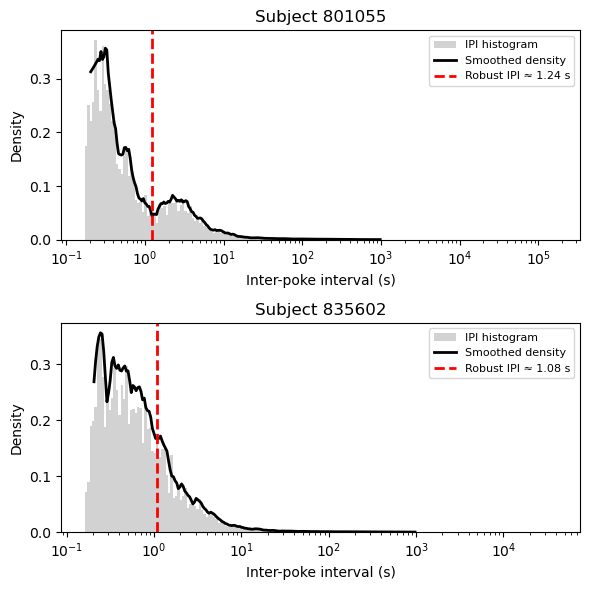

In [705]:
fig, poke_stats = compute_and_plot_ipi_distributions(poke_stats)
plt.show()


#### Bout-centric baseline poke rates

In [ ]:
def filter_baseline_pokes_by_ipi(
    poke_times,
    *,
    t_center,
    analysis_before,
    analysis_after,
    baseline_selection_before,
    baseline_selection_after,
    min_ipi,
):
    """
    Return poke timestamps (absolute) that:
      - lie in analysis window
      - are preceded by IPI >= min_ipi
      - whose preceding poke lies in baseline selection window
    """

    qualified = []

    for i in range(1, len(poke_times)):
        t = poke_times[i]
        t_prev = poke_times[i - 1]

        # Must lie within analysis window
        if not (t_center - analysis_before <= t <= t_center + analysis_after):
            continue

        # IPI criterion
        ipi = t - t_prev
        if ipi < min_ipi:
            continue

        # Preceding poke must lie within baseline-selection window
        t_prev_rel = t_prev - t_center
        if not (-baseline_selection_before <= t_prev_rel <= baseline_selection_after):
            continue

        qualified.append(t)

    return np.asarray(qualified)


def compute_timeseries_fold_change_exponential(
    poke_stats,
    pre_days: int = 3,
    analysis_before: float = 60 * 60,
    analysis_after: float = 20 * 60,
    baseline_selection_before: float = 30 * 60,
    baseline_selection_after: float = 30 * 60,
    min_ipi: float | None = None,
    epsilon_percentile: float = 5.0,
):
    import numpy as np

    results = {}

    for (subject, source_path), stats in poke_stats.items():
        t_master = np.asarray(stats["t"])
        r_master = np.asarray(stats["poke_rate"])
        poke_t = np.asarray(stats["poke_events"])
        odor_changes = list(zip(stats["odor_switch_t"], stats["odor_id"][1:]))

        # --------------------------------------------------
        # Resolve min_ipi for this session
        # --------------------------------------------------
        if min_ipi is None:
            resolved_min_ipi = stats.get("robust_ipi", np.nan)
        else:
            resolved_min_ipi = min_ipi

        # If no valid IPI threshold exists, skip safely
        if not np.isfinite(resolved_min_ipi):
            continue

        for i, (event_time, new_odor) in enumerate(odor_changes):
            baseline_rate_ts = []
            baseline_poke_counts = []

            # -----------------------------
            # Baseline days
            # -----------------------------
            for day in range(-pre_days, 0):
                day_event = event_time + day * 24 * 3600
                idx = np.where(poke_t > day_event)[0]
                if len(idx) < 2:
                    continue

                t_center = poke_t[idx[1]]

                qualified_pokes = filter_baseline_pokes_by_ipi(
                    poke_times=poke_t,
                    t_center=t_center,
                    analysis_before=analysis_before,
                    analysis_after=analysis_after,
                    baseline_selection_before=baseline_selection_before,
                    baseline_selection_after=baseline_selection_after,
                    min_ipi=resolved_min_ipi,
                )

                if qualified_pokes.size == 0:
                    continue

                baseline_poke_counts.append(len(qualified_pokes))

                mask = (t_master >= t_center - analysis_before) & (
                    t_master <= t_center + analysis_after
                )

                valid = np.zeros(mask.sum(), dtype=bool)
                t_slice = t_master[mask]

                dt = np.median(np.diff(t_master))
                for tp in qualified_pokes:
                    valid |= np.isclose(t_slice, tp, atol=dt)

                baseline_rate_ts.append(r_master[mask] * valid)

            if len(baseline_rate_ts) < 2:
                continue

            baseline_stack = np.vstack(baseline_rate_ts)
            baseline_mean = baseline_stack.mean(axis=0)
            baseline_std = baseline_stack.std(axis=0, ddof=1)
            sem_base = baseline_std / np.sqrt(baseline_stack.shape[0])
            ci_base = 1.960 * sem_base

            # -----------------------------
            # Day 0 (unchanged)
            # -----------------------------
            idx0 = np.where(poke_t > event_time)[0]
            if len(idx0) < 2:
                continue

            t0_center = poke_t[idx0[1]]
            mask0 = (t_master >= t0_center - analysis_before) & (
                t_master <= t0_center + analysis_after
            )

            t_axis = t_master[mask0] - t0_center
            day0_rate = r_master[mask0]

            # -----------------------------
            # Epsilon + fold change
            # -----------------------------
            all_rates = np.concatenate([baseline_stack.ravel(), day0_rate])
            nonzero = all_rates[all_rates > 0]
            if nonzero.size == 0:
                continue

            epsilon = np.percentile(nonzero, epsilon_percentile)

            raw_fc_days = ((day0_rate + epsilon) / (baseline_stack + epsilon)) - 1
            log_fc_days = np.log2((day0_rate + epsilon) / (baseline_stack + epsilon))

            mean_fc_raw = raw_fc_days.mean(axis=0)
            ci_fc_raw = 1.960 * (
                raw_fc_days.std(axis=0, ddof=1) / np.sqrt(baseline_stack.shape[0])
            )

            mean_fc_log = log_fc_days.mean(axis=0)
            ci_fc_log = 1.960 * (
                log_fc_days.std(axis=0, ddof=1) / np.sqrt(baseline_stack.shape[0])
            )

            results[
                (subject, source_path, f"odor_change_{i}", "timeseries_fold_change")
            ] = {
                "t_window": t_axis,
                "baseline_poke_rate_timeseries": baseline_stack,
                "baseline_mean_rate": baseline_mean,
                "baseline_ci_95": ci_base,
                "day0_rate": day0_rate,
                "mean_fc_raw": mean_fc_raw,
                "ci_95_fc_raw": ci_fc_raw,
                "mean_fc_log": mean_fc_log,
                "ci_95_fc_log": ci_fc_log,
                "epsilon_used": epsilon,
                "min_ipi_used": resolved_min_ipi,
                "n_baseline_days": baseline_stack.shape[0],
                "baseline_poke_counts_per_day": baseline_poke_counts,
                "n_baseline_pokes_total": int(np.sum(baseline_poke_counts)),
                "prev_odor": stats["odor_id"][i],
                "new_odor": new_odor,
            }

    return results


In [715]:
poke_rate_fc_exp = compute_timeseries_fold_change_exponential(
    poke_stats,
    pre_days=4,
    analysis_before=20 * 60,
    analysis_after=60 * 60,
    baseline_selection_before=6 * 60 * 60,
    baseline_selection_after=6 * 60 * 60,
)

In [716]:
poke_rate_fc_exp

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'timeseries_fold_change'): {'t_window': array([-1183.87497568, -1153.87497568, -1123.87497568, -1093.87497568,
         -1063.87497568, -1033.87497568, -1003.87497568,  -973.87497568,
          -943.87497568,  -913.87497568,  -883.87497568,  -853.87497568,
          -823.87497568,  -793.87497568,  -763.87497568,  -733.87497568,
          -703.87497568,  -673.87497568,  -643.87497568,  -613.87497568,
          -583.87497568,  -553.87497568,  -523.87497568,  -493.87497568,
          -463.87497568,  -433.87497568,  -403.87497568,  -373.87497568,
          -343.87497568,  -313.87497568,  -283.87497568,  -253.87497568,
          -223.87497568,  -193.87497568,  -163.87497568,  -133.87497568,
          -103.87497568,   -73.87497568,   -43.87497568,   -13.87497568,
            16.12502432,    46.12502432,    76.12502432,   106.12502432,
           136.12502432,

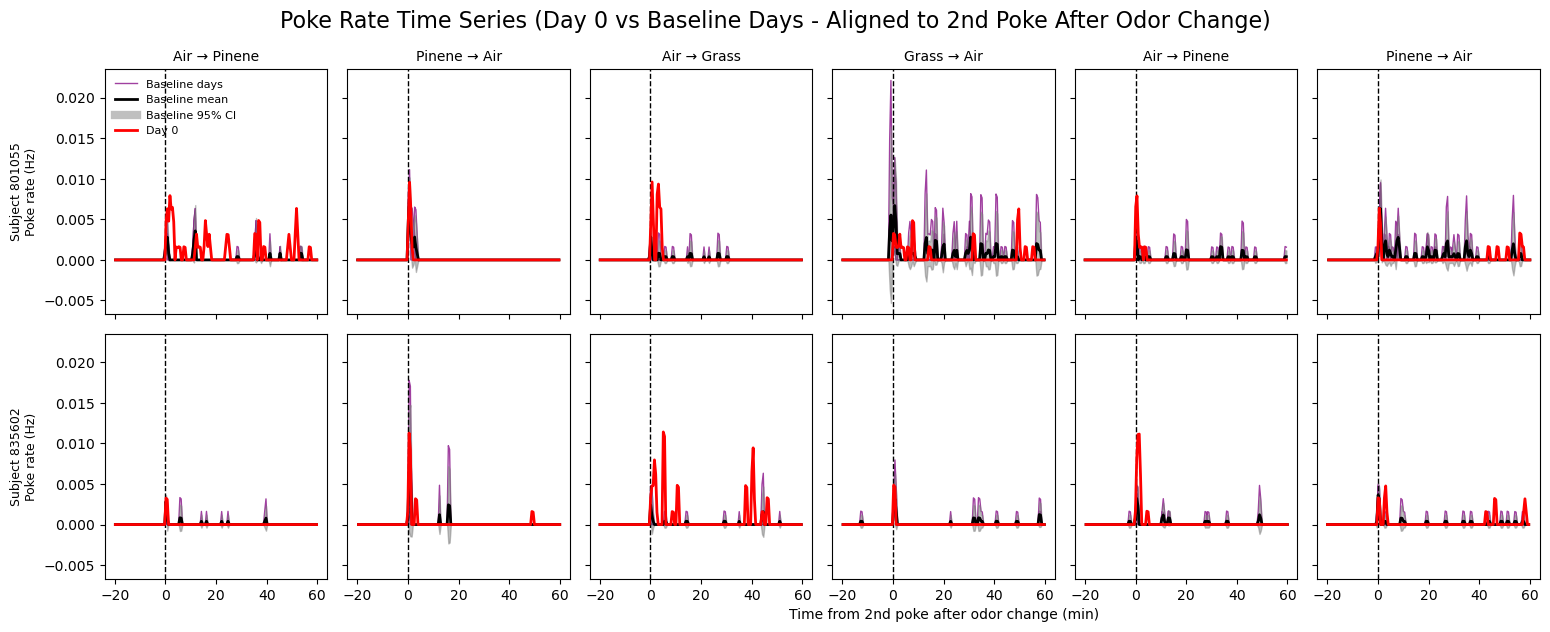

In [ ]:
# plot all poke rates
def plot_odor_switch_aligned_poke_rates_from_fc_exp(
    odor_switch_fc_exp,
    time_unit: str = "minutes",  # "seconds", "minutes", or "hours"
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Thin gray lines: individual baseline poke-rate time series
      - Thick black line: baseline mean
      - Gray shaded band: baseline 95% CI
      - Thick red line: day 0 poke-rate time series
      - Vertical dashed line at 0: 2nd poke alignment
    """

    # -------------------------
    # Time unit handling
    # -------------------------
    unit_scale = {
        "seconds": 1.0,
        "minutes": 60.0,
        "hours": 3600.0,
    }

    if time_unit not in unit_scale:
        raise ValueError("time_unit must be 'seconds', 'minutes', or 'hours'")

    scale = unit_scale[time_unit]
    time_label = {
        "seconds": "s",
        "minutes": "min",
        "hours": "h",
    }[time_unit]

    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)

    for key, data in odor_switch_fc_exp.items():
        if len(key) == 4 and key[3] == "timeseries_fold_change":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.6 * n_cols, 3.2 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, (subject, source_path) in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[(subject, source_path)]:
                ax.axis("off")
                continue

            data = sessions[(subject, source_path)][odor_change]

            t = data["t_window"] / scale
            baseline_stack = data["baseline_poke_rate_timeseries"]
            baseline_mean = data["baseline_mean_rate"]
            baseline_ci = data["baseline_ci_95"]
            day0_rate = data["day0_rate"]

            # ---- Individual baseline days ----
            for trace in baseline_stack:
                ax.plot(
                    t,
                    trace,
                    color="purple",
                    linewidth=1,
                    alpha=0.75,
                    zorder=1,
                )

            # ---- Baseline mean + CI ----
            ax.fill_between(
                t,
                baseline_mean - baseline_ci,
                baseline_mean + baseline_ci,
                color="gray",
                alpha=0.5,
                zorder=2,
            )

            ax.plot(
                t,
                baseline_mean,
                color="black",
                linewidth=2,
                zorder=3,
                label="Baseline mean",
            )

            # ---- Day 0 ----
            ax.plot(
                t,
                day0_rate,
                color="red",
                linewidth=2,
                zorder=4,
                label="Day 0",
            )

            # ---- Reference line ----
            ax.axvline(0, color="k", linestyle="--", linewidth=1)

            # ---- Titles ----
            if r == 0:
                prev_odor = data.get("prev_odor", "?")
                new_odor = data.get("new_odor", "?")
                ax.set_title(f"{prev_odor} → {new_odor}", fontsize=10)

            if c == 0:
                ax.set_ylabel(
                    f"Subject {subject}\nPoke rate (Hz)",
                    fontsize=9,
                )

            if r == n_rows - 1 and c == n_cols // 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )

    # -------------------------
    # Legend (single panel)
    # -------------------------
    legend_handles = [
        plt.Line2D(
            [], [], color="purple", linewidth=1, alpha=0.75, label="Baseline days"
        ),
        plt.Line2D([], [], color="black", linewidth=2, label="Baseline mean"),
        plt.Line2D(
            [], [], color="gray", linewidth=6, alpha=0.5, label="Baseline 95% CI"
        ),
        plt.Line2D([], [], color="red", linewidth=2, label="Day 0"),
    ]

    axes[0, 0].legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    plt.tight_layout()
    return fig


fig = plot_odor_switch_aligned_poke_rates_from_fc_exp(poke_rate_fc_exp)
fig.suptitle(
    "Poke Rate Time Series (Day 0 vs Baseline Days - Aligned to 2nd Poke After Odor Change)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_timeseries_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [718]:
def plot_odor_switch_aligned_fold_change_exponential(
    odor_switch_fc_exp,
    fold_change_type: str = "log",
    time_unit: str = "minutes",
):
    import matplotlib.pyplot as plt
    from collections import defaultdict

    # -------------------------
    # Time handling (unchanged)
    # -------------------------
    unit_scale = {"seconds": 1.0, "minutes": 60.0, "hours": 3600.0}
    scale = unit_scale[time_unit]
    time_label = {"seconds": "s", "minutes": "min", "hours": "h"}[time_unit]

    sessions = defaultdict(dict)
    for key, data in odor_switch_fc_exp.items():
        if len(key) == 4 and key[3] == "timeseries_fold_change":
            subject, source_path, odor_change, _ = key
            sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    fig, axes = plt.subplots(
        len(session_keys),
        len(odor_changes),
        figsize=(2.5 * len(odor_changes), 3 * len(session_keys)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for r, session in enumerate(session_keys):
        subject, source_path = session
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[session]:
                ax.axis("off")
                continue

            data = sessions[session][odor_change]

            t = data["t_window"] / scale
            if fold_change_type == "log":
                mean_fc = data["mean_fc_log"]
                ci = data["ci_95_fc_log"]
                ylabel = "log₂ Fold Change"
            else:
                mean_fc = data["mean_fc_raw"]
                ci = data["ci_95_fc_raw"]
                ylabel = "Raw Fold Change"

            # ---- Plot ----
            ax.fill_between(t, mean_fc - ci, mean_fc + ci, color="gray", alpha=0.4)
            ax.plot(t, mean_fc, color="black", linewidth=2)
            ax.axvline(0, color="k", linestyle="--", linewidth=1)
            ax.axhline(0, color="k", linestyle="--", linewidth=1)

            # ---- Baseline poke count annotation ----
            n_pokes = data.get("n_baseline_pokes_total", 0)
            ax.text(
                0.02,
                0.95,
                f"Baseline poke bouts: N={n_pokes}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
            )

            if r == 0:
                ax.set_title(
                    f"{data['prev_odor']} → {data['new_odor']}",
                    fontsize=10,
                )

            if c == 0:
                ax.set_ylabel(f"Subject {subject}\n{ylabel}", fontsize=9)

            if r == len(session_keys) - 1 and c == len(odor_changes) // 2:
                ax.set_xlabel(
                    f"Time from 2nd poke after odor change ({time_label})",
                    fontsize=10,
                )

    plt.tight_layout()
    return fig

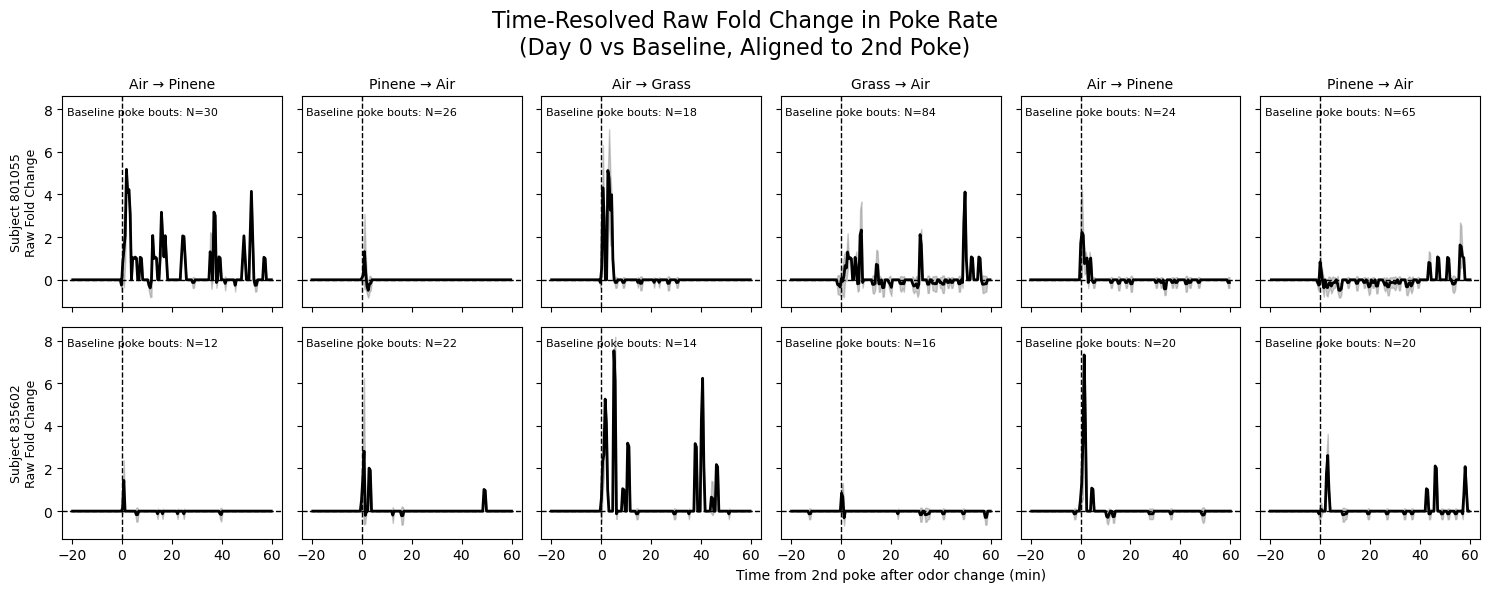

In [719]:
# raw fold change figure
fig = plot_odor_switch_aligned_fold_change_exponential(
    poke_rate_fc_exp,
    fold_change_type="raw",
    time_unit="minutes",
)
fig.suptitle(
    "Time‑Resolved Raw Fold Change in Poke Rate\n(Day 0 vs Baseline, Aligned to 2nd Poke)",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_raw_fold_change_exp.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

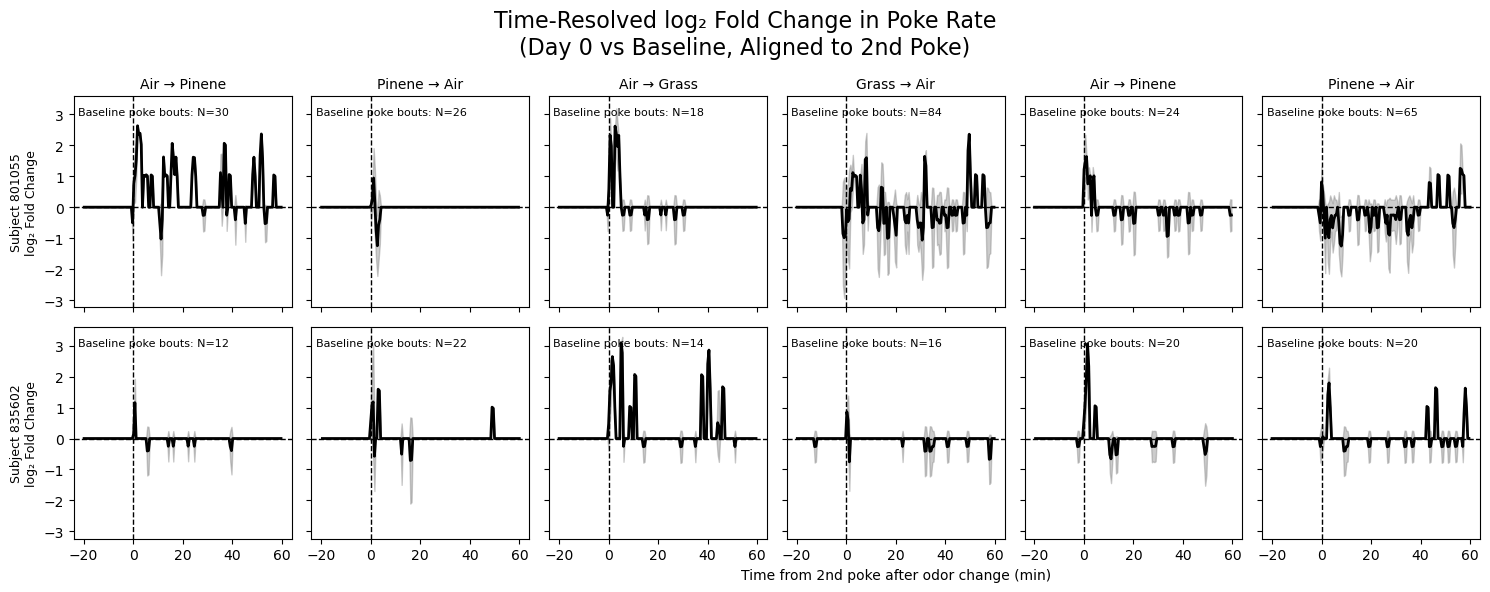

In [720]:
# log fold change figure
fig = plot_odor_switch_aligned_fold_change_exponential(
    poke_rate_fc_exp,
    fold_change_type="log",
    time_unit="minutes",
)

fig.suptitle(
    "Time‑Resolved log₂ Fold Change in Poke Rate\n(Day 0 vs Baseline, Aligned to 2nd Poke)",
    fontsize=16,
)

fig.tight_layout()
fig.savefig(
    result_dir.joinpath("poke_rate_log_fold_change_exp.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#### Cummlative pokes per odor change

In [ ]:
# Compute 24 hr cumulative poke count for day 0 and baseline days
def compute_windowed_cumulative_poke_count(
    poke_stats: Dict[Tuple[str, str], Dict[str, Any]],
    pre_days: int = 3,
    window_size: float = 24 * 3600,  # 24 hours in seconds
) -> Dict[Tuple[str, str, str, str], Dict[str, Any]]:
    """
    Compute cumulative poke count in a fixed window for day 0 and baseline days.

    Additionally computes baseline mean and 95% CI across baseline days
    (time-resolved) and stores it as its own dictionary key.
    """

    cumulative_counts = {}

    for (subject, source_path), stats in poke_stats.items():
        poke_events = stats["poke_events"]
        odor_changes = list(zip(stats["odor_switch_t"], stats["odor_id"][1:]))

        for i, (event_time, new_odor) in enumerate(odor_changes):
            baseline_counts = []
            baseline_times = []

            # -------------------------
            # Baseline days
            # -------------------------
            for day in range(-pre_days, 0):
                start_time = event_time + day * 24 * 3600
                poke_after = poke_events[poke_events > start_time]

                if len(poke_after) < 2:
                    continue

                second_poke_time = poke_after[1]
                window_start = second_poke_time
                window_end = window_start + window_size

                pokes_in_window = poke_events[
                    (poke_events >= window_start) & (poke_events < window_end)
                ]

                t_rel = pokes_in_window - window_start
                cum_counts = np.arange(1, len(t_rel) + 1)

                baseline_counts.append(cum_counts)
                baseline_times.append(t_rel)

                cumulative_counts[
                    (subject, source_path, f"odor_change_{i}", f"day_{day}")
                ] = {
                    "t_window": t_rel,
                    "cumulative_count": cum_counts,
                    "new_odor": new_odor,
                    "prev_odor": stats["odor_id"][i],
                }

            # -------------------------
            # Day 0
            # -------------------------
            poke_after_day0 = poke_events[poke_events > event_time]
            if len(poke_after_day0) < 2:
                continue

            common_time = np.arange(0, window_size, 60)  # every minute
            second_poke_time_day0 = poke_after_day0[1]
            window_start = second_poke_time_day0
            window_end = window_start + window_size

            pokes_day0 = poke_events[
                (poke_events >= window_start) & (poke_events < window_end)
            ]
            t_day0 = pokes_day0 - window_start
            cum_day0 = np.arange(1, len(t_day0) + 1)
            day0_interp = np.interp(
                common_time, t_day0, cum_day0, left=0, right=cum_day0[-1]
            )

            cumulative_counts[(subject, source_path, f"odor_change_{i}", "day_0")] = {
                "t_window": common_time,
                "cumulative_count": day0_interp,
                "new_odor": new_odor,
                "prev_odor": stats["odor_id"][i],
            }

            # -------------------------
            # Baseline mean + CI
            # -------------------------
            baseline_counts.append(cum_counts)
            baseline_times.append(t_rel)

            # Interpolate to a common time axix
            baseline_interp = np.zeros((len(baseline_counts), len(common_time)))
            for j, (counts, times) in enumerate(zip(baseline_counts, baseline_times)):
                if len(counts) == 0:
                    baseline_interp[j] = np.zeros_like(common_time)
                else:
                    baseline_interp[j] = np.interp(
                        common_time, times, counts, left=0, right=counts[-1]
                    )

            mean_base = np.nanmean(baseline_interp, axis=0)

            n_days = np.sum(~np.isnan(baseline_interp), axis=0)
            std = np.nanstd(baseline_interp, axis=0, ddof=1)

            sem = std / np.sqrt(n_days)
            # tcrit = t.ppf(0.975, n_days - 1)
            ci_95 = 1.960 * sem

            cumulative_counts[
                (subject, source_path, f"odor_change_{i}", "baseline_cumulative_stats")
            ] = {
                "t_window": common_time,
                "mean_cumulative": mean_base,
                "ci_95": ci_95,
                "n_days_used": n_days,
                "new_odor": new_odor,
                "prev_odor": stats["odor_id"][i],
            }

    return cumulative_counts


In [412]:
cum_pokes = compute_windowed_cumulative_poke_count(poke_stats, pre_days=3)
cum_pokes

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-3'): {'t_window': array([   0.        ,    5.00214434, 1690.82444811, 4256.20982409,
         4256.40064001, 4256.60012913]),
  'cumulative_count': array([1, 2, 3, 4, 5, 6]),
  'new_odor': 'Pinene',
  'prev_odor': 'Air'},
 ('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'day_-2'): {'t_window': array([0.00000000e+00, 3.49742079e+01, 6.23611104e+02, 6.63078880e+02,
         6.63267008e+02, 6.68947296e+02, 6.73938912e+02, 2.10395987e+03,
         2.12575411e+03, 2.12802285e+03, 2.69724589e+03, 3.18836445e+03,
         3.80024294e+03, 4.16515635e+03, 5.12636806e+03, 6.09782954e+03,
         6.98083219e+03, 8.36677408e+03, 8.54669386e+03, 8.60776314e+03,
         8.99360256e+03, 9.00334211e+03, 1.31839786e+04, 1.45728219e+04,
         1.57647110e+04, 1.64218302e+04, 1

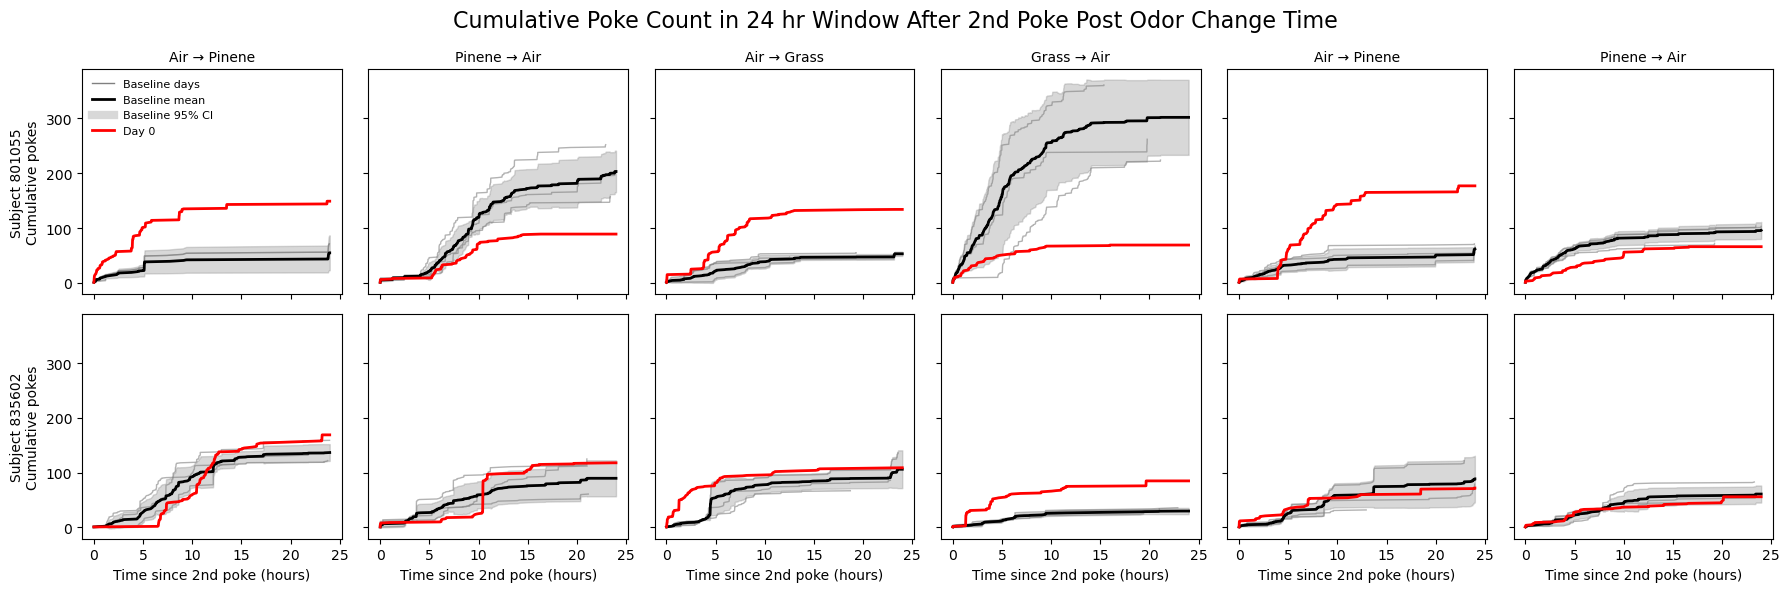

In [413]:
def plot_cumulative_poke_counts(
    cumulative_counts,
):
    """
    Rows: subject / session
    Columns: odor change

    Per panel:
      - Gray thin lines: baseline days
      - Black thick line: baseline mean cumulative count
      - Gray shaded band: baseline 95% CI
      - Red thick line: day 0
    """
    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(lambda: defaultdict(dict))

    for key, data in cumulative_counts.items():
        subject, source_path, odor_change, label = key
        sessions[(subject, source_path)][odor_change][label] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    fig, axes = plt.subplots(
        len(session_keys),
        len(odor_changes),
        figsize=(3 * len(odor_changes), 3 * len(session_keys)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot
    # -------------------------
    for r, session in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]
            entries = sessions[session].get(odor_change)

            if entries is None:
                ax.axis("off")
                continue

            # Baseline days
            for k, v in entries.items():
                if k.startswith("day_-"):
                    ax.plot(
                        v["t_window"] / 3600,
                        v["cumulative_count"],
                        color="gray",
                        alpha=0.6,
                        linewidth=1,
                    )

            # Baseline mean + CI
            base = entries.get("baseline_cumulative_stats")
            if base is not None:
                t = base["t_window"] / 3600
                mean = base["mean_cumulative"]
                ci = base["ci_95"]

                ax.fill_between(
                    t,
                    mean - ci,
                    mean + ci,
                    color="gray",
                    alpha=0.3,
                )

                ax.plot(
                    t,
                    mean,
                    color="black",
                    linewidth=2,
                )

            # Day 0
            if "day_0" in entries:
                ax.plot(
                    entries["day_0"]["t_window"] / 3600,
                    entries["day_0"]["cumulative_count"],
                    color="red",
                    linewidth=2,
                )

            # Labels
            if r == 0:
                ax.set_title(f"{base['prev_odor']} → {base['new_odor']}", fontsize=10)

            if c == 0:
                ax.set_ylabel(f"Subject {session[0]}\nCumulative pokes")

            if r == len(session_keys) - 1:
                ax.set_xlabel("Time since 2nd poke (hours)")

    # Legend
    legend_handles = [
        plt.Line2D([], [], color="gray", linewidth=1, label="Baseline days"),
        plt.Line2D([], [], color="black", linewidth=2, label="Baseline mean"),
        plt.Line2D(
            [], [], color="gray", linewidth=6, alpha=0.3, label="Baseline 95% CI"
        ),
        plt.Line2D([], [], color="red", linewidth=2, label="Day 0"),
    ]

    axes[0, 0].legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    fig.tight_layout()
    return fig


fig = plot_cumulative_poke_counts(cum_pokes)
fig.suptitle(
    "Cumulative Poke Count in 24 hr Window After 2nd Poke Post Odor Change Time",
    fontsize=16,
)
fig.tight_layout()
fig.savefig(
    result_dir.joinpath("cumulative_poke_count_odor_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Poke duration
- Averge poke duration difference over post poke window (report n = pokes).
- Poke duration over N pokes.
- Poke duration during burst/poking bouts.

In [414]:
poke_stats

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv'): {'t': array([1.00479126e-02, 3.00100479e+01, 6.00100479e+01, ...,
         4.21176001e+06, 4.21179001e+06, 4.21182001e+06]),
  'poke_rate': array([0.00166667, 0.00158538, 0.        , ..., 0.        , 0.        ,
         0.        ]),
  'poke_events': array([1.00479126e-02, 2.30428736e+02, 3.31759680e+02, ...,
         4.21169701e+06, 4.21183093e+06, 4.21183348e+06]),
  'poke_durations': array([0.27660799, 0.50105619, 0.38211203, ..., 0.29350376, 0.16691208,
         0.12799978]),
  'odor_id': ['Air', 'Pinene', 'Air', 'Grass', 'Air', 'Pinene', 'Air'],
  'first_poke_t': [0.01004791259765625,
   624163.8850235939,
   1210071.9658875465,
   1820301.669599533,
   2438658.824511528,
   3028975.077152729,
   3646231.2347836494],
  'odor_switch_t': [599591.3093757629,
   1205951.309375763,
   1814531.309375763,
   2422211.309375763,
   3024131.309375763,
   3633311.309375763]},
 

In [ ]:
def extract_durations(
    start_time,
    poke_t,
    durations,
    mode="n_pokes",
    n_pokes=25,
    window_size=2 * 3600,
    outlier_k=3.0,
):
    """
    Extract poke durations relative to the second poke after start_time.

    For mode="time_window", the window is:
        [second_poke_time, second_poke_time + window_size]

    Extreme outliers (hardware artifacts) are replaced with the next valid poke.
    """

    # Find pokes after start_time
    idx = np.where(poke_t > start_time)[0]
    if len(idx) < 2:
        return np.array([])

    second_poke_idx = idx[1]
    second_poke_time = poke_t[second_poke_idx]

    # -------------------------
    # Extract raw durations
    # -------------------------
    if mode == "n_pokes":
        raw = durations[second_poke_idx : second_poke_idx + n_pokes].copy()

    else:
        # Window anchored to the SECOND poke
        end_time = second_poke_time + window_size

        # Consistent indexing: build mask *after* second poke
        in_window = (poke_t >= second_poke_time) & (poke_t <= end_time)

        raw = durations[in_window].copy()

    # Always expect at least the second poke itself
    if raw.size == 0:
        return raw

    # -------------------------
    # Identify outliers (IQR method)
    # -------------------------
    if raw.size < 4:
        return raw

    q1 = np.percentile(raw, 25)
    q3 = np.percentile(raw, 75)
    iqr = q3 - q1
    upper_thresh = q3 + outlier_k * iqr

    is_outlier = raw > upper_thresh
    if not np.any(is_outlier):
        return raw

    # -------------------------
    # Replace outliers with next valid poke
    # -------------------------
    cleaned = raw.copy()

    for i in np.where(is_outlier)[0]:
        for j in range(i + 1, len(raw)):
            if raw[j] <= upper_thresh:
                cleaned[i] = raw[j]
                break
        else:
            valid_before = cleaned[:i][~is_outlier[:i]]
            if valid_before.size > 0:
                cleaned[i] = valid_before[-1]

    return cleaned


# ------------------------------------------------------------
# Compute poke duration comparisons
# ------------------------------------------------------------
def compute_poke_duration_comparison(
    poke_stats: Dict[Tuple[str, str], Dict[str, Any]],
    pre_days: int = 3,
    mode: str = "n_pokes",  # "n_pokes" or "time_window"
    n_pokes: int = 25,
    window_size: float = 2 * 3600,
):
    """
    Compute poke-duration distributions for baseline days and day 0,
    and perform paired statistical comparisons (day 0 vs each baseline day)
    for each odor change event.

    Returns
    -------
    dict
        Keyed by:
        (subject, source_path, odor_change_i, "poke_duration_comparison")

        Each entry contains:
        - durations: dict of np.ndarrays per day
        - stats: p-value + test name per baseline day
    """

    results = {}

    for (subject, source_path), stats in poke_stats.items():
        poke_t = stats["poke_events"]
        durations = stats["poke_durations"]
        odor_changes = list(zip(stats["odor_switch_t"], stats["odor_id"][1:]))

        for i, (event_time, new_odor) in enumerate(odor_changes):
            day_data = {}

            # -------------------------
            # Baseline days
            # -------------------------
            for day in range(-pre_days, 0):
                start = event_time + day * 24 * 3600
                durs = extract_durations(
                    start,
                    poke_t,
                    durations,
                    mode=mode,
                    n_pokes=n_pokes,
                    window_size=window_size,
                )
                day_data[f"day_{day}"] = durs

            # -------------------------
            # Day 0
            # -------------------------
            day0_durs = extract_durations(
                event_time,
                poke_t,
                durations,
                mode=mode,
                n_pokes=n_pokes,
                window_size=window_size,
            )
            day_data["day_0"] = day0_durs

            # -------------------------
            # Statistics vs day 0
            # -------------------------
            stats_out = {}

            for key, base_durs in day_data.items():
                if key == "day_0":
                    continue

                n = min(len(base_durs), len(day0_durs))
                if n < 5:
                    stats_out[key] = {"p": np.nan, "test": None}
                    continue

                d0 = day0_durs[:n]
                db = base_durs[:n]

                # Normality check
                normal = shapiro(d0).pvalue > 0.05 and shapiro(db).pvalue > 0.05

                if normal:
                    _, p = ttest_rel(d0, db)
                    test = "paired t-test"
                else:
                    _, p = wilcoxon(d0, db)
                    test = "wilcoxon"

                stats_out[key] = {"p": p, "test": test}

            results[
                (subject, source_path, f"odor_change_{i}", "poke_duration_comparison")
            ] = {
                "durations": day_data,
                "stats": stats_out,
                "prev_odor": stats["odor_id"][i],
                "new_odor": new_odor,
            }

    return results

In [530]:
def plot_poke_duration_comparison(results):
    """
    One figure:
      Rows    = subject/session
      Columns = odor change

    Categorical plot with:
      - jittered durations (stripplot-style)
      - dashed mean line per distribution
      - mean ± std
      - significance lines drawn in FIGURE coordinates (never overlap, never clip)
    """
    # -------------------------
    # Organize data
    # -------------------------
    sessions = defaultdict(dict)
    for (subject, source_path, odor_change, _), data in results.items():
        sessions[(subject, source_path)][odor_change] = data

    session_keys = list(sessions.keys())
    odor_changes = sorted(
        {oc for s in sessions.values() for oc in s.keys()},
        key=lambda x: int(x.split("_")[2]),
    )

    n_rows = len(session_keys)
    n_cols = len(odor_changes)

    # Small, stable figure size
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.5 * n_cols, 4.0 * n_rows),
        sharey=True,
        squeeze=False,
    )

    # -------------------------
    # Plot distributions
    # -------------------------
    for r, session in enumerate(session_keys):
        subject, _ = session

        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]

            if odor_change not in sessions[session]:
                ax.axis("off")
                continue

            data = sessions[session][odor_change]
            durations = data["durations"]
            stats = data["stats"]

            days = sorted(
                durations.keys(),
                key=lambda d: 0 if d == "day_0" else int(d.split("_")[1]),
            )

            x_pos = np.arange(len(days))

            for i, day in enumerate(days):
                y = durations.get(day, [])
                if len(y) == 0:
                    continue

                color = "red" if day == "day_0" else "gray"

                jitter = np.random.normal(0, 0.06, size=len(y))
                ax.scatter(
                    i + jitter,
                    y,
                    s=14,
                    color=color,
                    alpha=0.6,
                    zorder=2,
                )

                mean = np.mean(y)
                std = np.std(y)

                ax.errorbar(
                    i,
                    mean,
                    yerr=std,
                    color="black",
                    lw=1.6,
                    capsize=4,
                    zorder=3,
                )

                ax.hlines(
                    mean,
                    i - 0.15,
                    i + 0.15,
                    linestyles="solid",
                    color="black",
                    linewidth=1.2,
                )

                ax.text(
                    i,
                    mean + std + 0.02,
                    f"N={len(y)}",
                    ha="center",
                    fontsize=7,
                )

            ax.set_xticks(x_pos)
            days_labels = [d.replace("day_", "Day ") for d in days]
            ax.set_xticklabels(days_labels, rotation=45, fontsize=8)

            if r == 0:
                ax.set_title(
                    f"{data['prev_odor']} → {data['new_odor']}",
                    fontsize=10,
                )

            if c == 0:
                ax.set_ylabel(f"Subject {subject}\nPoke duration (s)")

    # -------------------------
    # Significance annotations in FIGURE coordinates
    # -------------------------
    fig.canvas.draw()  # ensure positions are known

    for r, session in enumerate(session_keys):
        for c, odor_change in enumerate(odor_changes):
            ax = axes[r, c]
            if odor_change not in sessions[session]:
                continue

            data = sessions[session][odor_change]
            stats = data["stats"]
            durations = data["durations"]

            days = sorted(
                durations.keys(),
                key=lambda d: 0 if d == "day_0" else int(d.split("_")[1]),
            )

            if "day_0" not in days:
                continue

            x_day0 = days.index("day_0")

            # Axis bounding box in figure coordinates
            bbox = ax.get_position()
            left, right = bbox.x0, bbox.x1
            top = bbox.y1

            # Annotation ladder above subplot
            y_step = 0.035
            y_offset = -0.1
            y_line = top + y_offset

            for i, day in enumerate(days):
                if day == "day_0":
                    continue

                stat = stats.get(day, {})
                p = stat.get("p")
                test = stat.get("test")

                if p is None or np.isnan(p):
                    label = "n/a"
                elif p < 0.05:
                    # label = f"* (p={p:.3g}, {test})"
                    label = f"* (p={p:.2g})"
                else:
                    # label = f"n.s. ({test})"
                    label = "n.s."

                # Map category positions to figure x-coordinates
                x1 = left + (right - left) * (i + 0.1) / (len(days) - 1)
                x2 = left + (right - left) * (x_day0 - 0.1) / (len(days) - 1)

                fig.lines.append(
                    plt.Line2D(
                        [x1, x2],
                        [y_line, y_line],
                        transform=fig.transFigure,
                        color="black",
                        lw=1.0,
                    )
                )

                fig.text(
                    (x1 + x2) / 2,
                    y_line + 0.006,
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

                y_line += y_step

    return fig

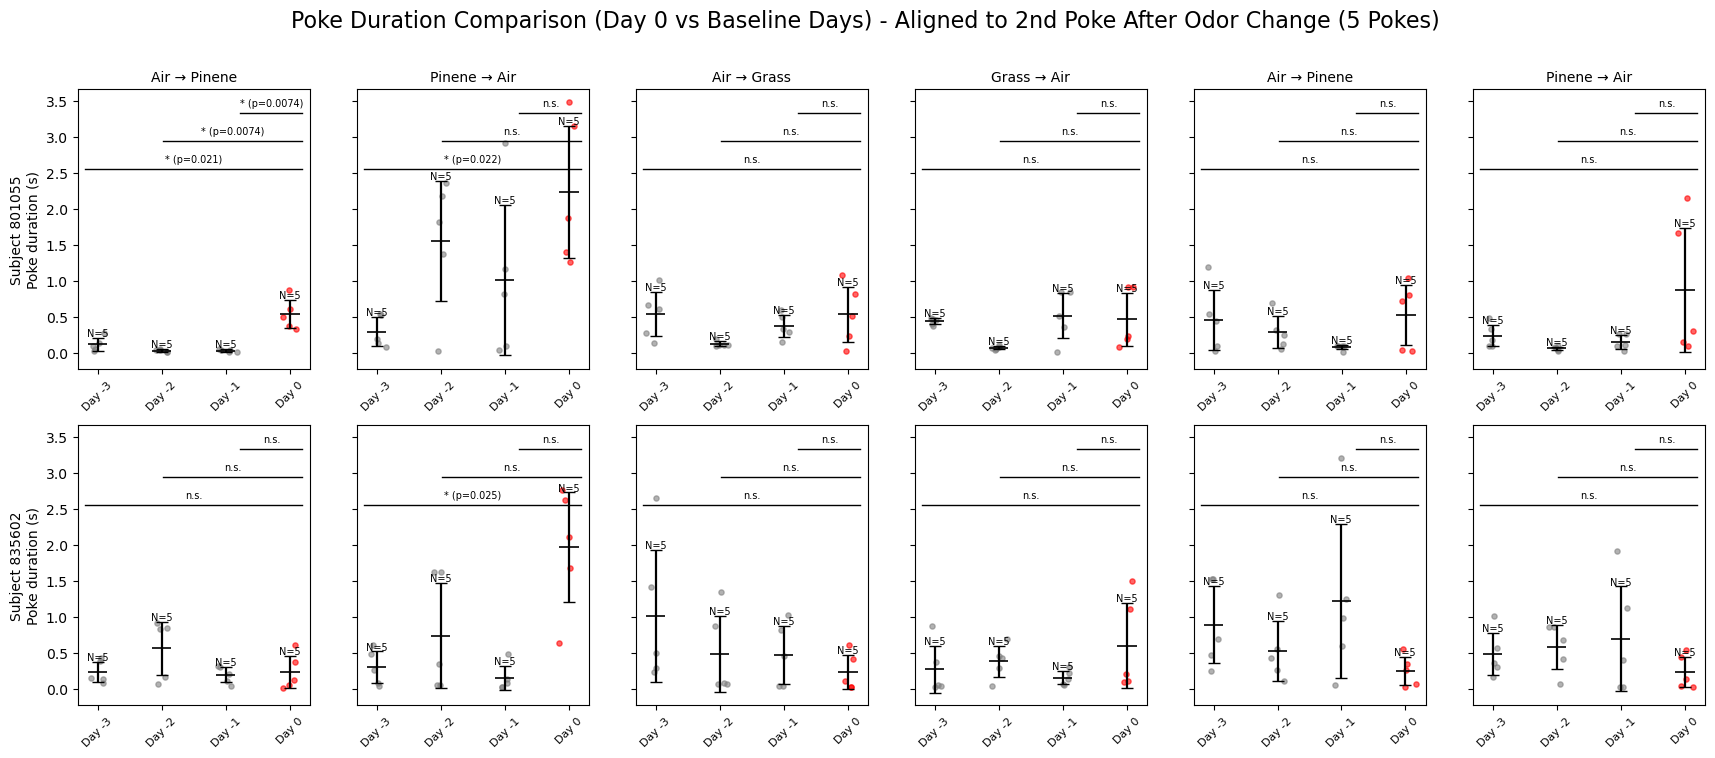

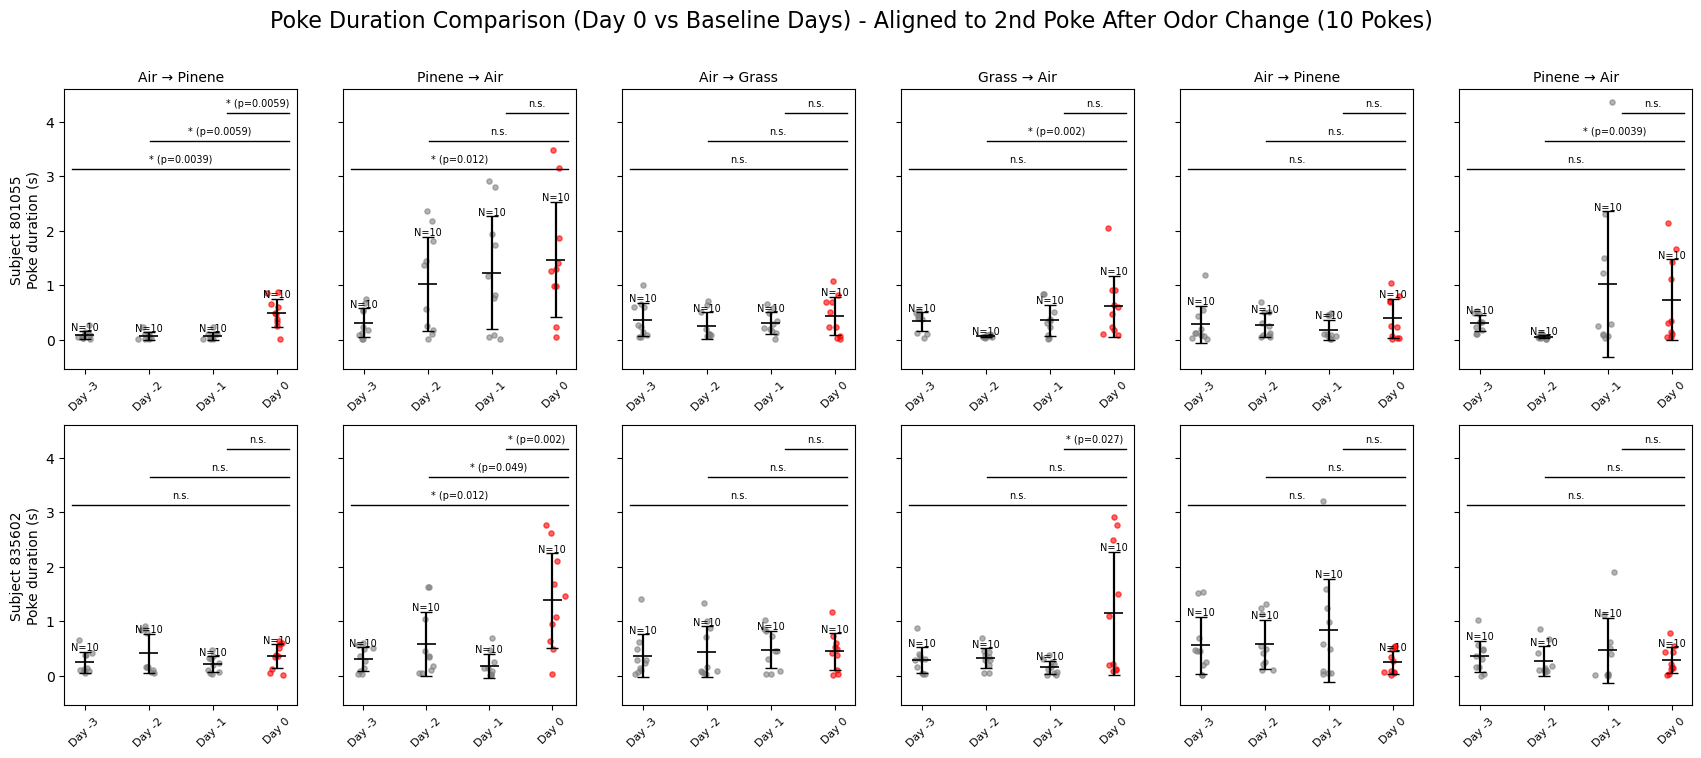

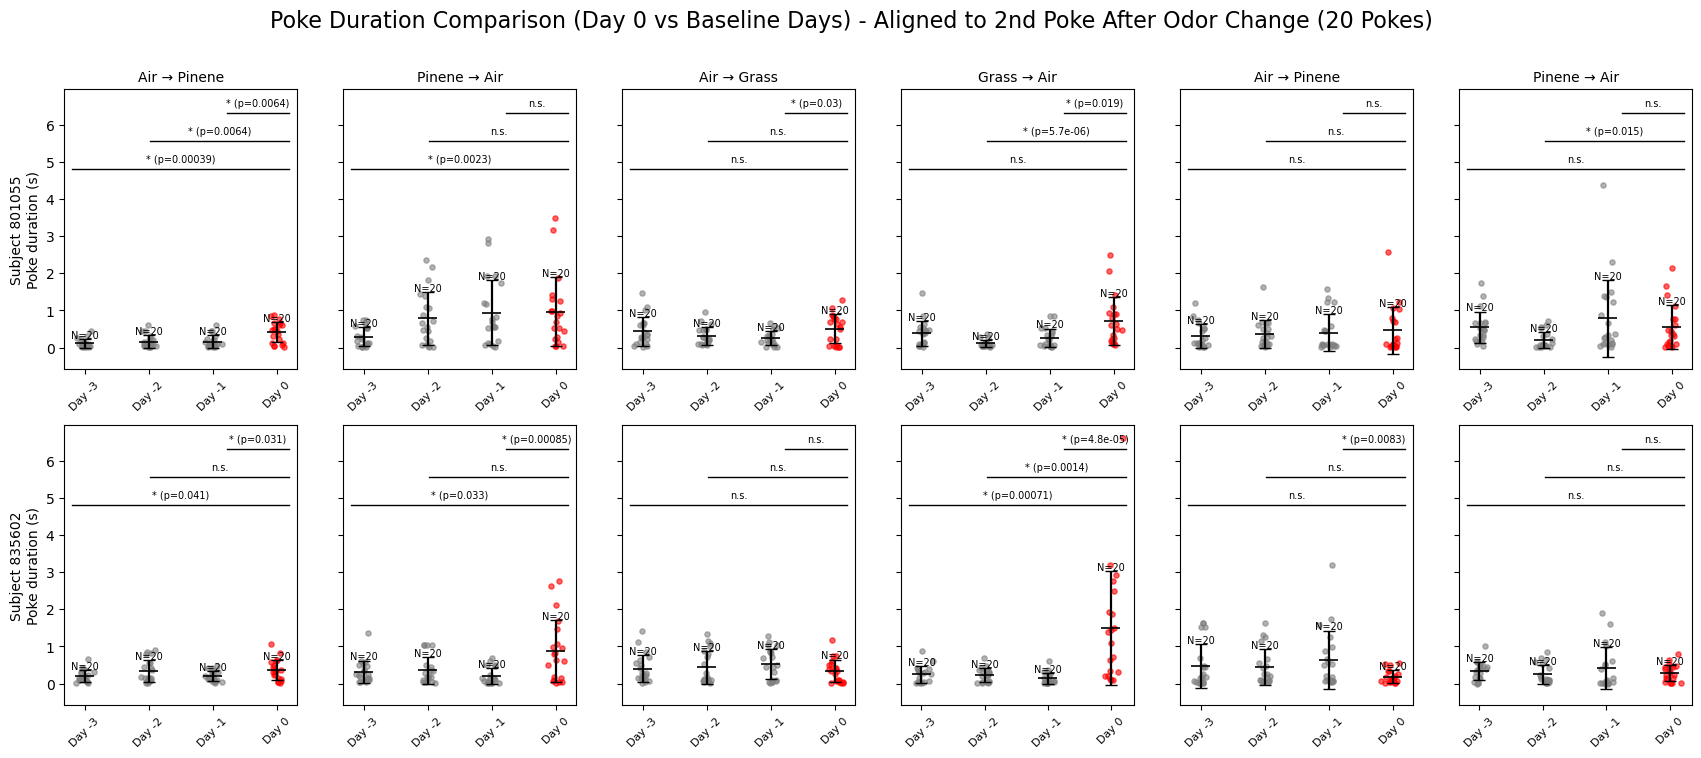

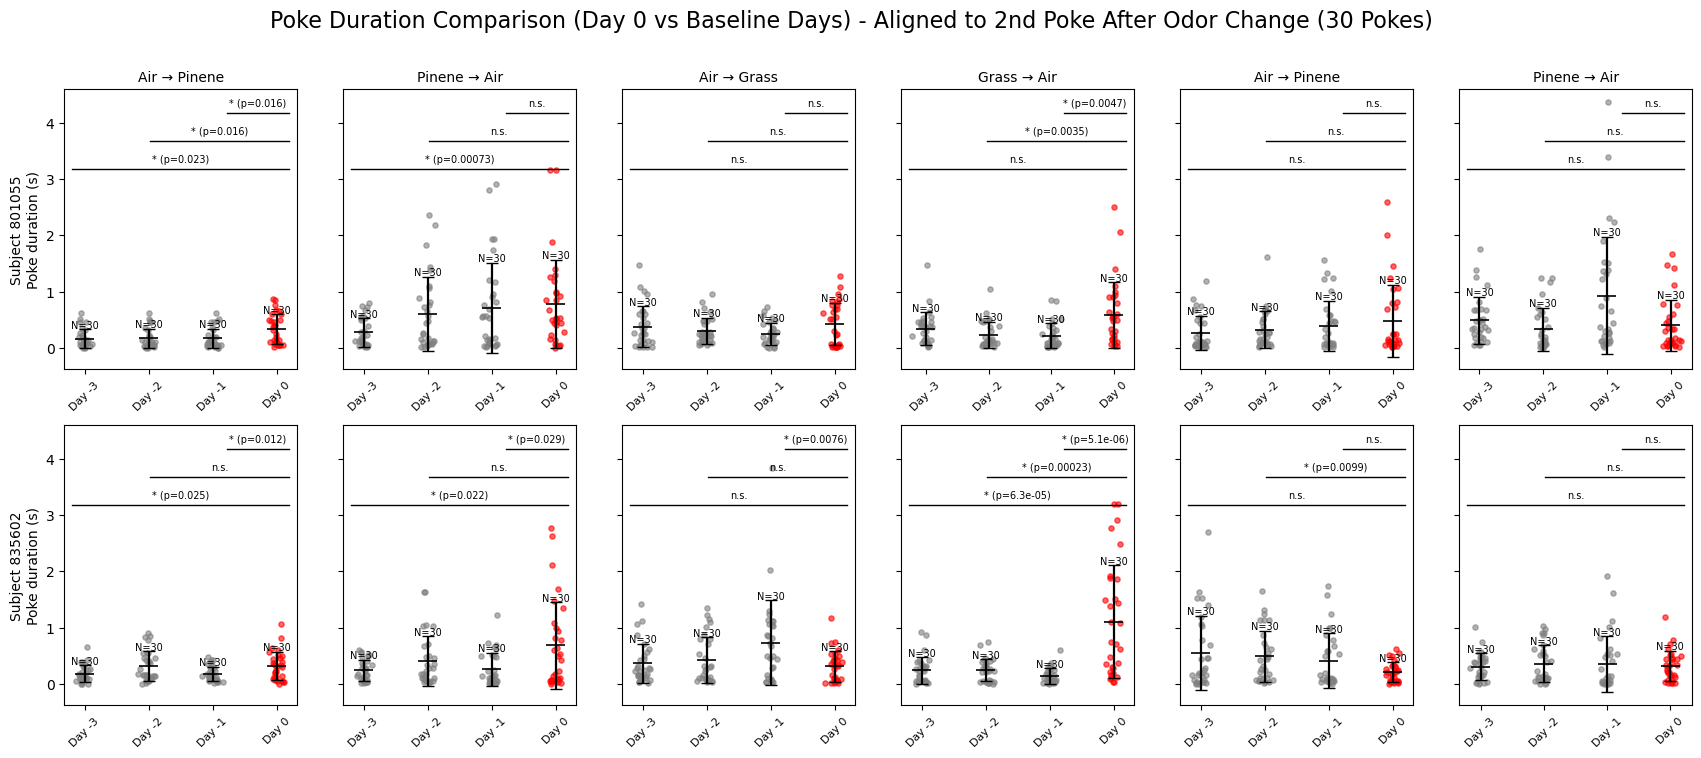

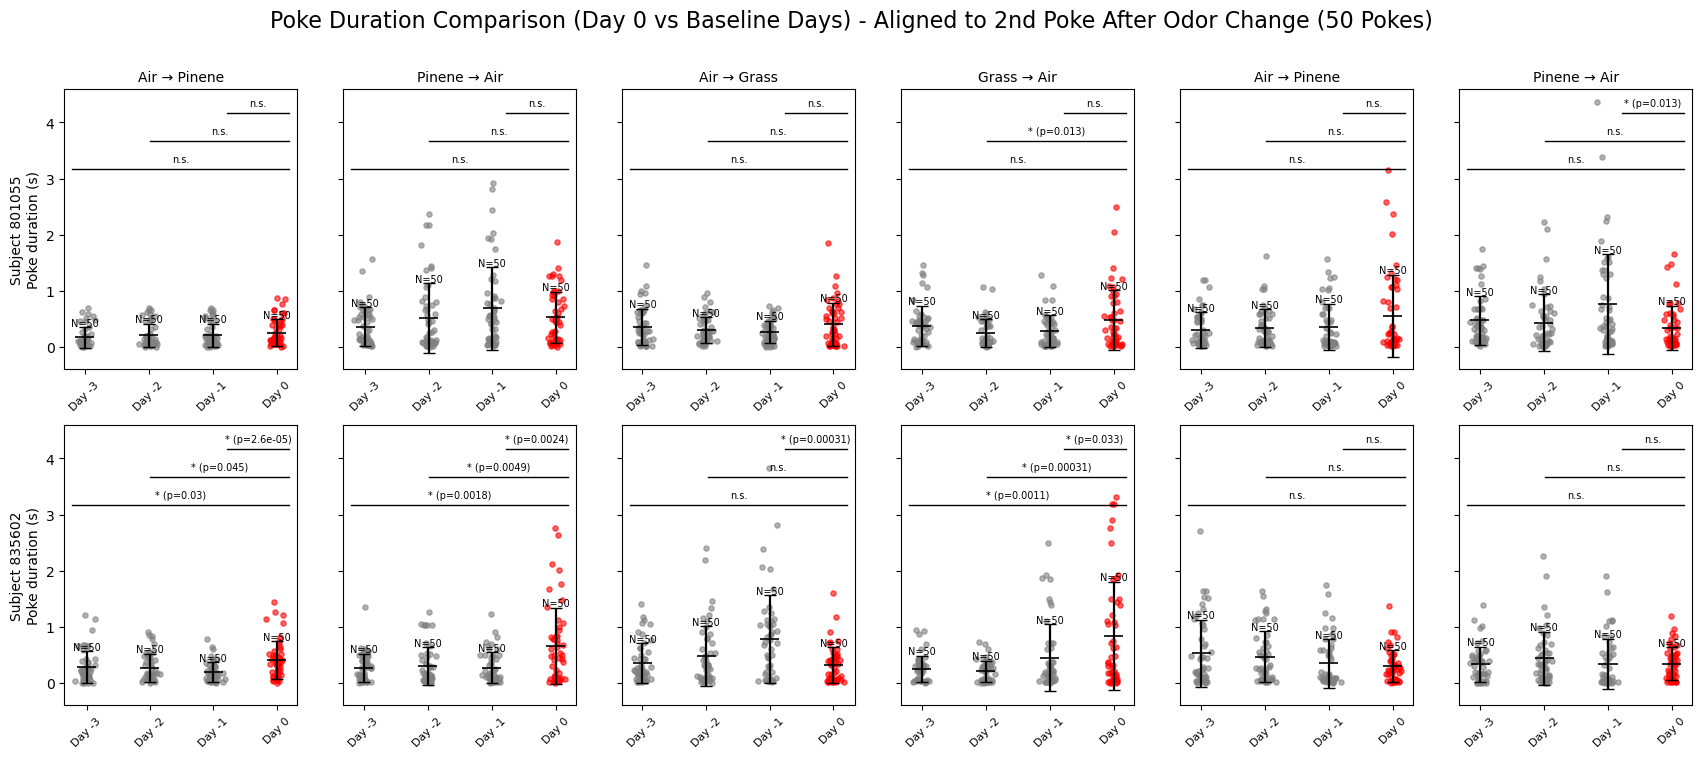

In [532]:
# Poke duration comparison results
n_pokes_list = [5, 10, 20, 30, 50]

for n in n_pokes_list:
    poke_dur_results = compute_poke_duration_comparison(
        poke_stats,
        pre_days=3,
        mode="n_pokes",
        n_pokes=n,
    )

    fig = plot_poke_duration_comparison(poke_dur_results)
    fig.suptitle(
        f"Poke Duration Comparison (Day 0 vs Baseline Days) - Aligned to 2nd Poke After Odor Change ({n} Pokes)",
        fontsize=16,
    )
    fig.savefig(
        result_dir.joinpath(f"poke_duration_comparison_odor_switch_{n}_pokes.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [533]:
# Poke duration comparison results using time window method
poke_dur_results_time = compute_poke_duration_comparison(
    poke_stats,
    pre_days=3,
    mode="time_window",
    window_size=2 * 3600,
)

In [534]:
poke_dur_results_time

{('801055',
  'C:\\Users\\brandon.pratt\\Desktop\\results\\801055\\2026-01-06T22-49-36\\delphi_qc_dataframe.csv',
  'odor_change_0',
  'poke_duration_comparison'): {'durations': {'day_-3': array([0.13903999, 0.26838398, 0.09532785, 0.01811218, 0.04911995,
          0.04911995]),
   'day_-2': array([0.03148794, 0.05673599, 0.03977585, 0.00467205, 0.45638418,
          0.00687981, 0.10022402, 0.23532772, 0.10467196, 0.10422373,
          0.318048  , 0.02348804, 0.04137564, 0.04419136, 0.62137604,
          0.45974398, 0.19824028]),
   'day_-1': array([0.03148794, 0.05673599, 0.03977585, 0.00467205, 0.45638418,
          0.00687981, 0.10022402, 0.23532772, 0.10467196, 0.10422373,
          0.318048  , 0.02348804, 0.04137564, 0.04419136, 0.62137604,
          0.45974398, 0.19824028]),
   'day_0': array([8.77280235e-01, 3.23999882e-01, 4.94240284e-01, 3.71616364e-01,
          6.07903957e-01, 4.69727993e-01, 6.58848286e-01, 2.44575977e-01,
          1.19357109e-02, 8.56735706e-01, 7.6611185

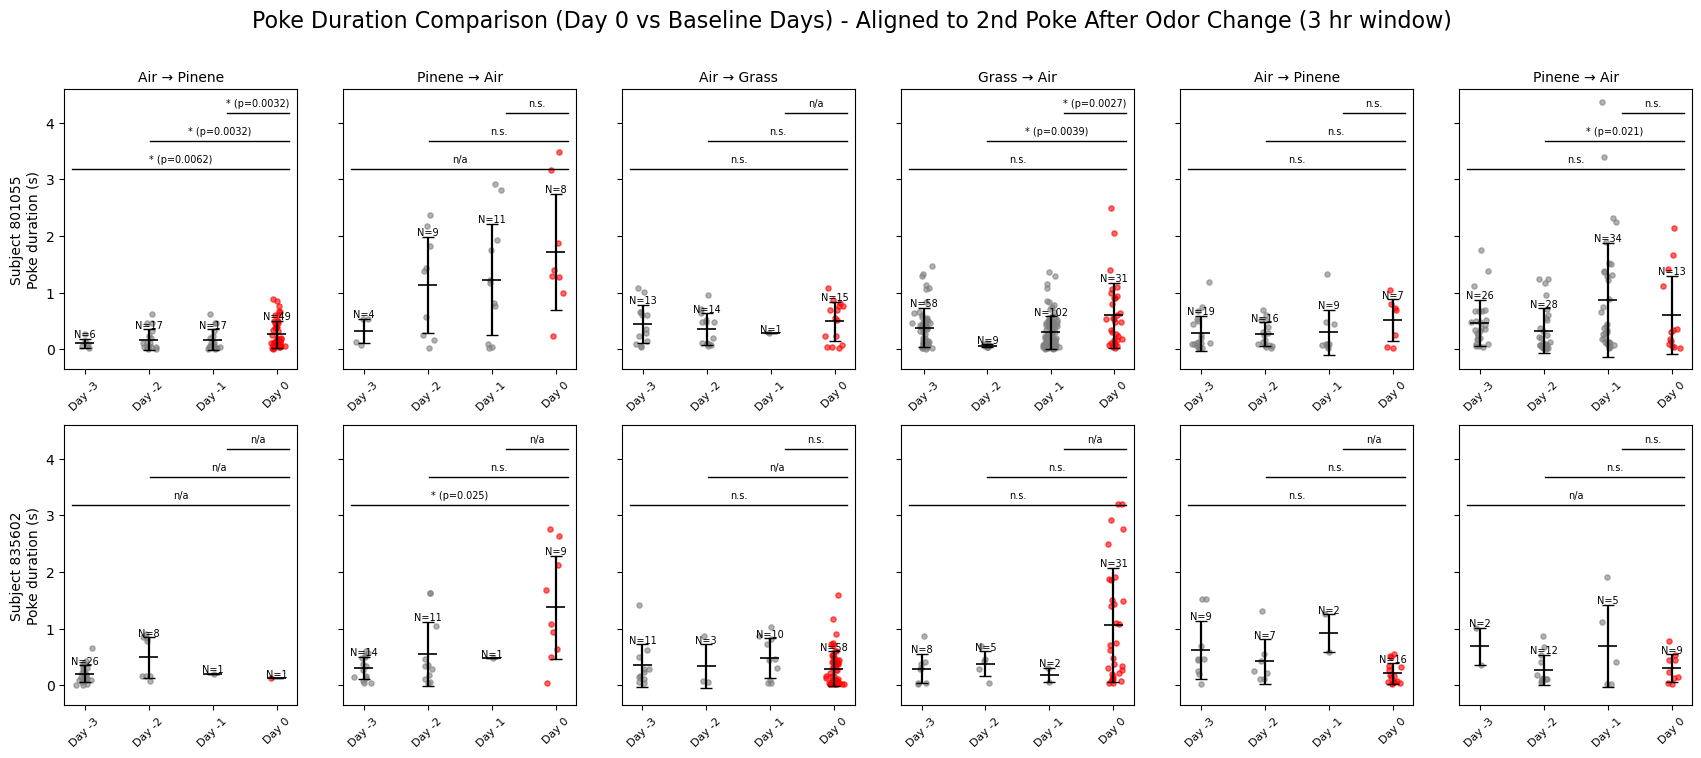

In [535]:
# Plot poke duration comparison using time window method
fig = plot_poke_duration_comparison(poke_dur_results_time)
fig.suptitle(
    f"Poke Duration Comparison (Day 0 vs Baseline Days) - Aligned to 2nd Poke After Odor Change (3 hr window)",
    fontsize=16,
)
fig.savefig(
    result_dir.joinpath(f"poke_duration_comparison_odor_switch_time_window.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()